## Libaries

In [4]:
import numpy as np
import pandas as pd
from pathlib import Path
import sys
import os

from statsmodels.stats.anova import AnovaRM
from scipy.stats import ttest_rel
from itertools import combinations
from statsmodels.stats.multitest import multipletests
from sklearn.metrics import confusion_matrix
from scipy.stats import friedmanchisquare
from scipy.stats import wilcoxon
import itertools

import matplotlib.pyplot as plt
import torch

current_dir = Path().resolve().parent.parent
sys.path.append(str(current_dir))

from src.utilities.load_and_visualize_data import DataAnalysis      # noqa: F402

In [5]:
# ----- Global style -----

plt.rcParams.update({

    # ---------------- Font ----------------
    "font.family": "serif",
    "font.serif": ["Times New Roman"],

    # # Math text similar to Times
    "mathtext.fontset": "stix",

    # ---------------- Font sizes ----------------
    "font.size": 10,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,

    # ---------------- Line widths ----------------
    "axes.linewidth": 0.367,
    "lines.linewidth": 0.367,

    # Tick width
    "xtick.major.width": 0.367,
    "ytick.major.width": 0.367,

    # ---------------- Figure ----------------
    "figure.dpi": 400,
    "savefig.transparent": True,
    "savefig.bbox": "tight",
})

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

### Functions

In [6]:
def extract_model_specs(sherpa_log_folder = 'SingleNet_LSTM_EMG'):
    # Extract file
    sherpa_info_path = Path().resolve() / f"loggings/subject_independent/{sherpa_log_folder}/all_subjects/SHERPA_results.pt"
    if not os.path.exists(sherpa_info_path):
        raise FileExistsError(sherpa_info_path)
    
    data = torch.load(sherpa_info_path, weights_only=False)

    
    best_vloss = min(
        data["trials"],
        key=lambda x: np.mean(x["validation_loss"])
    )
    
    best_tacc = max(
        data['trials'],
        key = lambda x: x['test_accuracy']
    )

    # cm = confusion_matrix(best_vloss['labels'], best_vloss['predictions'])
    # print('Network : ', sherpa_log_folder)
    # print(cm)

    bv_summary_vloss = best_vloss['validation_loss']
    bv_summary_vacc = best_vloss['validation_accuracy']
    bv_summary_acc = best_vloss['test_accuracy']

    ba_summary_vloss = best_tacc['validation_loss']
    ba_summary_vacc = best_tacc['validation_accuracy']
    ba_summary_acc = best_tacc['test_accuracy']

    return bv_summary_vloss, ba_summary_vloss, bv_summary_acc, ba_summary_acc, bv_summary_vacc, ba_summary_vacc

def mm_to_inches(mm):
    return mm / 25.4

sherpa_log_folder = 'FusionNet_CNN+LSTM'
sherpa_info_path = Path().resolve() / f"loggings/subject_independent_without_CV/{sherpa_log_folder}/all_subjects/model.pth"
if not os.path.exists(sherpa_info_path):
    raise FileExistsError(sherpa_info_path)

data = torch.load(sherpa_info_path, map_location='cpu')

In [7]:
print(data.keys())

state_dict = data["model_state"]

# for name in state_dict.keys():
#     print(name, state_dict[name].shape)

fusion_key1 = "fusion.classifier.0.weight"
fusion_key2 = "fusion.classifier.3.weight"

W = state_dict[fusion_key2].detach().cpu()

print(W.shape)
print(W)

eeg_weights = W[:, :3]
emg_weights = W[:, 3:]
print("Mean absolute EEG weight:", eeg_weights.abs().mean().item(), 'shape:', eeg_weights.shape)
print("Mean absolute EMG weight:", emg_weights.abs().mean().item(), 'shape:', emg_weights.shape)

for class_idx in range(W.shape[0]):
    eeg_strength = eeg_weights[class_idx].abs().mean().item()
    emg_strength = emg_weights[class_idx].abs().mean().item()

    print(
        f"Class {class_idx}: "
        f"EEG={eeg_strength:.4f}, EMG={emg_strength:.4f}"
    )

dict_keys(['model_name', 'model_state', 'model_args', 'optimizer_state_dict', 'hyperparameters'])
torch.Size([5, 8])
tensor([[-1.6184, -1.5607,  0.2418,  0.2745, -0.5979, -0.8560, -1.5857,  0.0936],
        [-0.0705, -0.4516, -1.3060, -0.9148, -0.2956,  0.0174,  0.2400, -1.8034],
        [ 0.1995, -0.0865,  0.2260,  0.2597,  0.2098, -0.7659, -1.3539,  0.0797],
        [ 0.3294,  0.0303,  0.1065,  0.1784, -0.1378, -0.0038,  0.2304, -1.1189],
        [ 0.3666,  0.0643, -0.6999, -0.4609,  0.3083, -0.5456,  0.1357, -0.0679]])
Mean absolute EEG weight: 0.49052172899246216 shape: torch.Size([5, 3])
Mean absolute EMG weight: 0.5014235973358154 shape: torch.Size([5, 5])
Class 0: EEG=1.1403, EMG=0.6815
Class 1: EEG=0.6093, EMG=0.6542
Class 2: EEG=0.1707, EMG=0.5338
Class 3: EEG=0.1554, EMG=0.3339
Class 4: EEG=0.3769, EMG=0.3037


## Data to analyse

In [7]:
#=====================================#
# Subject-dependent EEG across models #
#=====================================#
subj_EEG_acc = {
    
"LSTM": [30.56, 33.33, 40.74, 33.33, 29.63, 34.85, 41.33, 64.20, 33.33, 33.33, 33.33, 33.33, 33.33, 35.90, 33.33, 30.77, 39.13],    

"CNN+LSTM": [70.83, 64.29, 61.73, 33.33, 35.80, 33.33, 45.33, 77.78, 33.33, 49.38, 52.38, 50.00, 46.15, 37.18, 26.39, 37.18, 47.83],

"CNN+LSTM+Attention": [77.78, 63.10, 62.96, 53.33, 50.62, 50.00, 58.67, 80.25, 44.87, 60.49, 57.14, 56.41, 50.00, 58.97, 45.83, 43.59, 50.72]}

print(np.mean(subj_EEG_acc["LSTM"]), np.std(subj_EEG_acc["LSTM"]))
print(np.mean(subj_EEG_acc["CNN+LSTM"]), np.std(subj_EEG_acc["CNN+LSTM"]))
print(np.mean(subj_EEG_acc["CNN+LSTM+Attention"]), np.std(subj_EEG_acc["CNN+LSTM+Attention"]))

36.10294117647058 7.714083197942261
47.190588235294115 14.104795792916025
56.748823529411766 10.019372929980928


## Subject-dependent across models

### [EEG]: Load data and statistics

In [11]:
accuracies = subj_EEG_acc
models = list(accuracies.keys())

# Compare models within each subject
print('#-------------Compare models within each subject-------------#\n')
stat, p = friedmanchisquare(
    accuracies['LSTM'],
    accuracies['CNN+LSTM'],
    accuracies['CNN+LSTM+Attention']
)

print(f"Friedman test: stat={stat:.4f}, p={p:.4f}")


print('\n#-------------Corresponding wilcoxon-------------#')
pairs = list(itertools.combinations(range(len(models)), 2))

for i, j in pairs:
    i_id = models[i]
    j_id = models[j]
    stat, p = wilcoxon(accuracies[i_id], accuracies[j_id])
    print(f"Model {i_id} vs {j_id}: p={p:.4f}, stat={stat:.4f}")

#-------------Compare models within each subject-------------#

Friedman test: stat=9.5789, p=0.0083

#-------------Corresponding wilcoxon-------------#
Model LSTM vs CNN+LSTM: p=0.0679, stat=0.0000
Model LSTM vs CNN+LSTM+Attention: p=0.0625, stat=0.0000
Model CNN+LSTM vs CNN+LSTM+Attention: p=0.0625, stat=0.0000


In [ ]:
'''Repeated measure anova
#======================#
# Convert to dataframe #
#======================#
models = list(subj_EEG_acc.keys())
data = np.array([subj_EEG_acc[m]['EEG'] for m in models]).T  # shape: (subjects, models)

df = pd.DataFrame(data, columns=models)
df["subject"] = range(len(df))

# Long format (required for ANOVA)
df_long = df.melt(id_vars=["subject"], var_name="model", value_name="accuracy")

#==========#
# RM-ANOVA #
#==========#
anova = AnovaRM(df_long, depvar="accuracy", subject="subject", within=["model"])
res = anova.fit()

print("\n=== RM-ANOVA ===")
print(res)

#=========================#
# Post-hoc paired t-tests #
#=========================#
print("\n=== Post-hoc (paired t-tests, Holm corrected) ===")

p_vals = []
pairs = []

for m1, m2 in combinations(models, 2):
    t_stat, p = ttest_rel(df[m1], df[m2])
    p_vals.append(p)                        # p-value between models
    pairs.append((m1, m2))                  # Model pair

reject, p_corrected, _, _ = multipletests(p_vals, method='holm')

for i, (m1, m2) in enumerate(pairs):
    print(f"{m1} vs {m2}: p={p_corrected[i]:.4f}, significant={reject[i]}")
'''


### [EEG] Plot accuracies

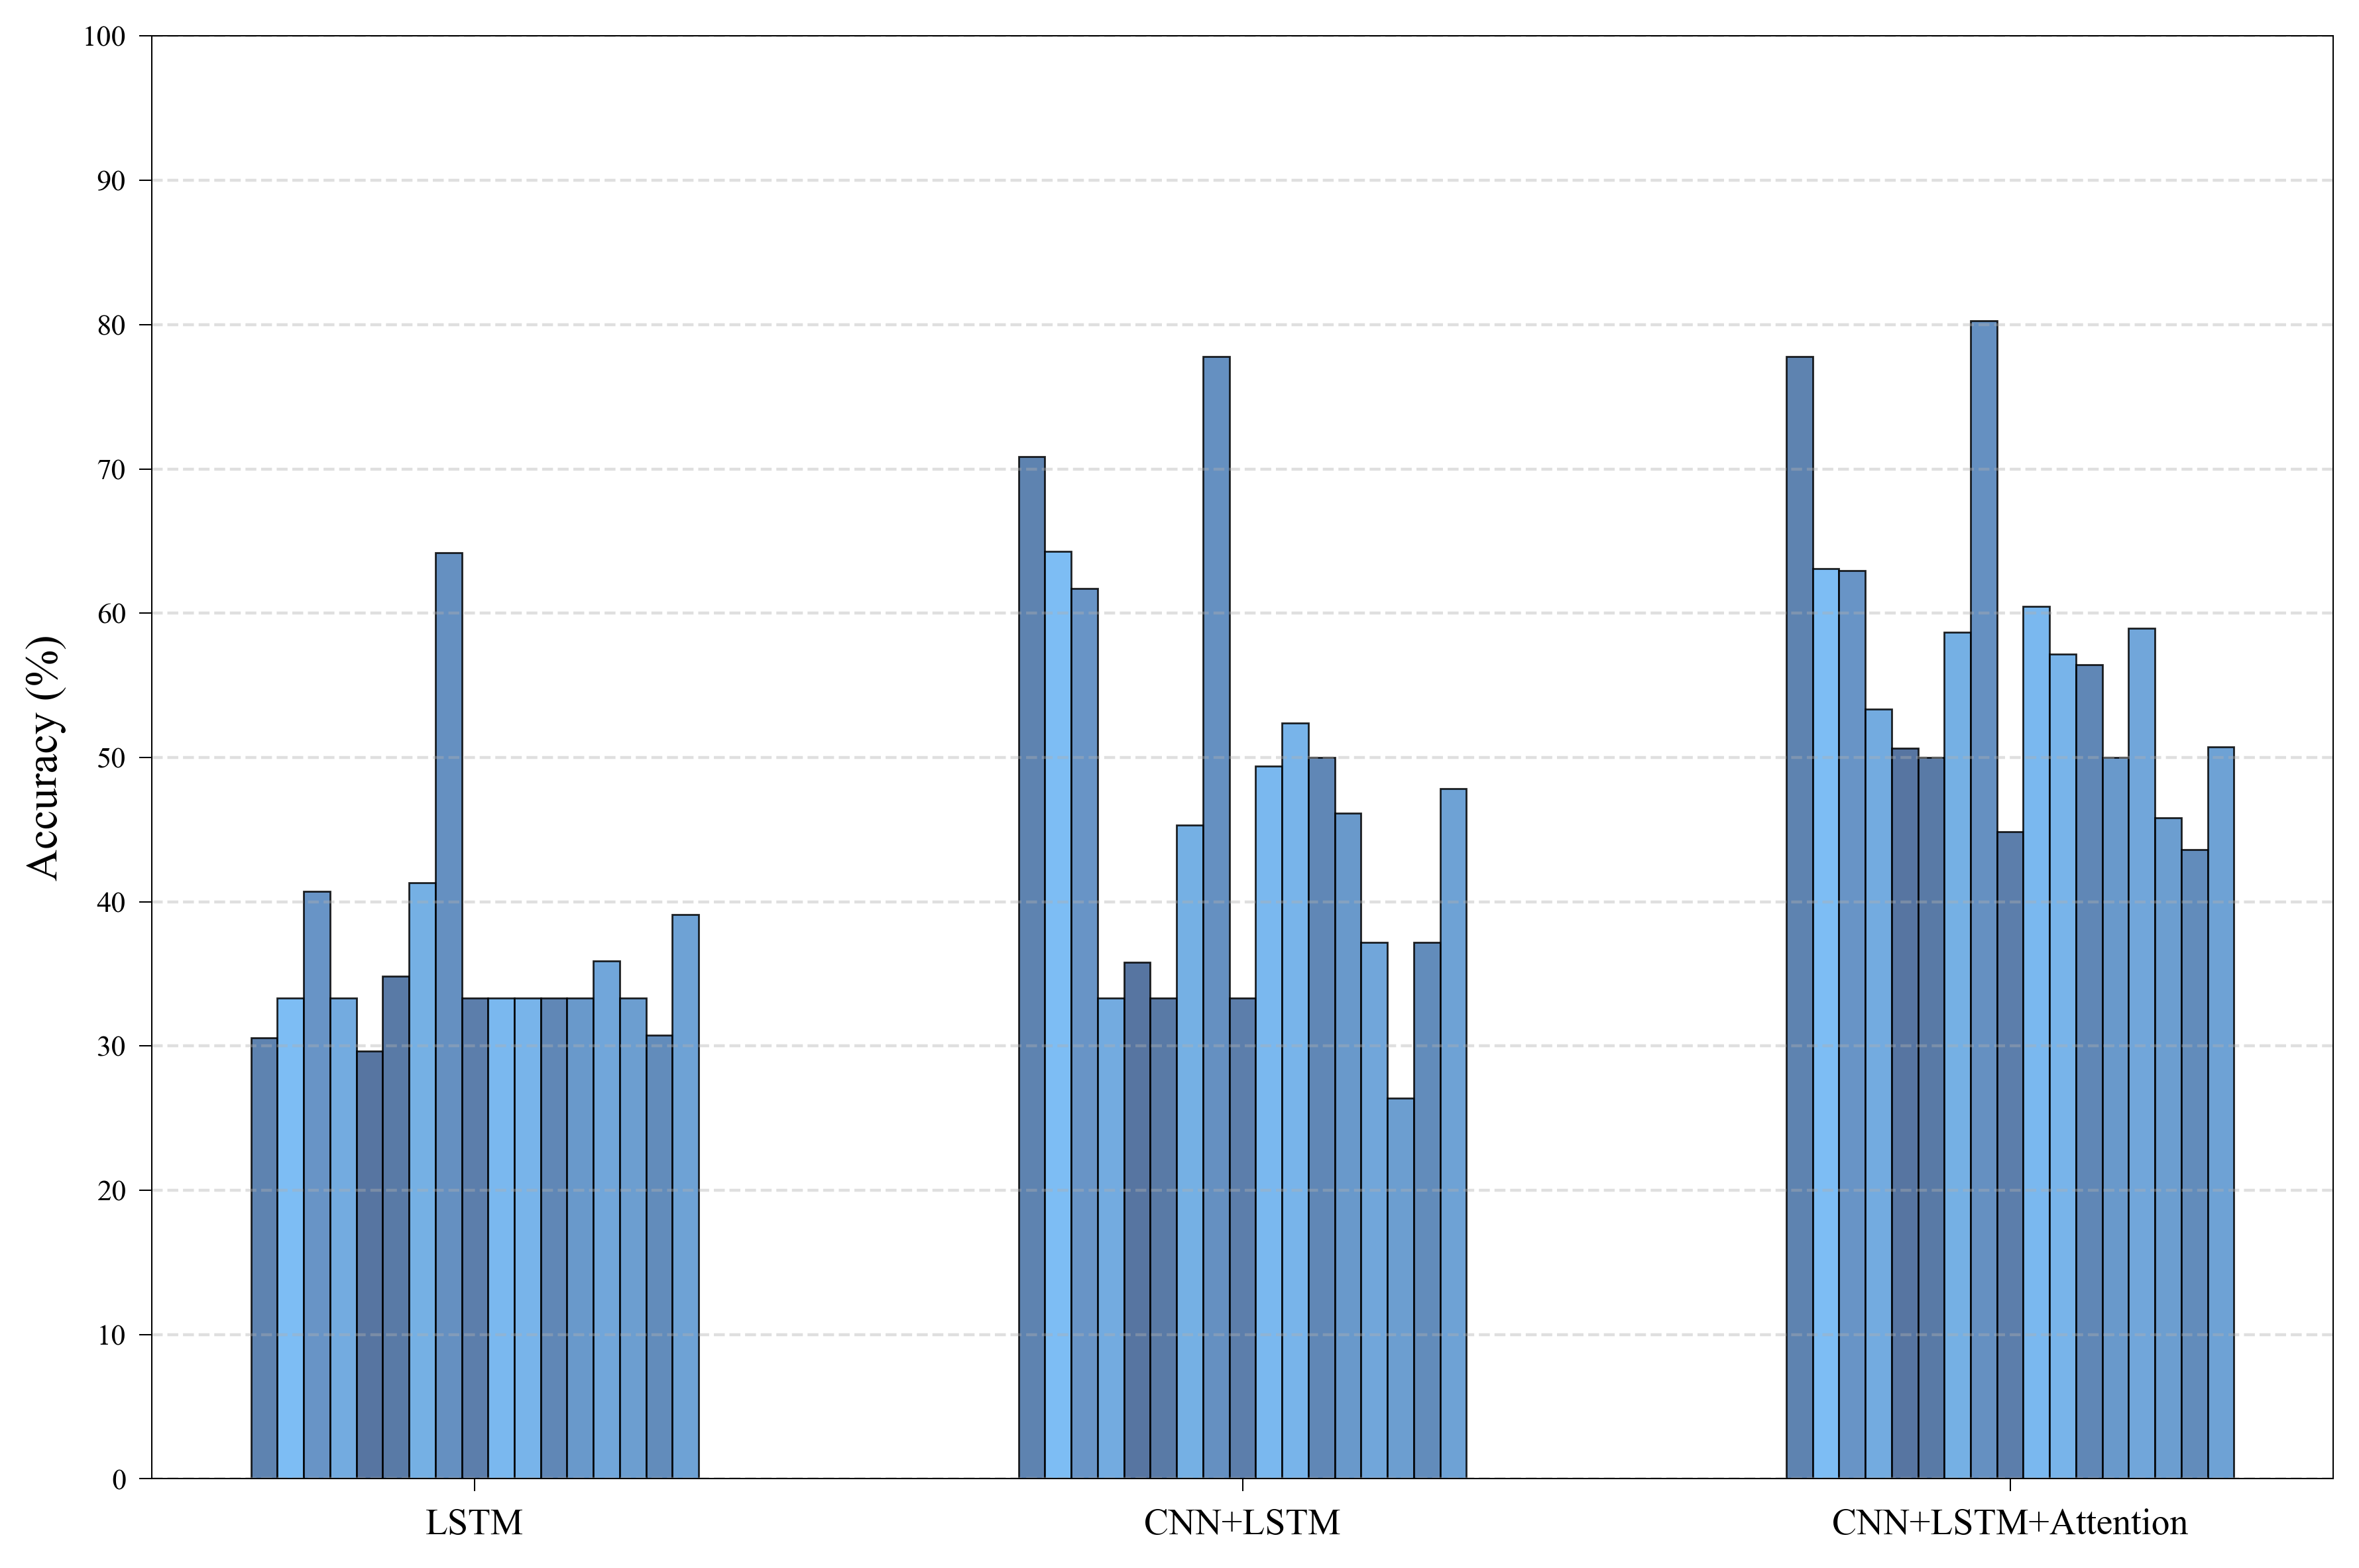

In [9]:
import matplotlib.colors as mcolors

def _plot_subject_accuracy_hierarchical(subject_ids, accuracies, architectures):
    """
    Plot grouped bars with hierarchical x-axis:
    Architecture -> Modality

    Parameters
    ----------
    subject_ids : list
        Example: ['S1','S2','S3']

    accuracies : dict
        Dictionary structured like:

        {
            "LSTM": {
                "EEG": [...],
                "EMG": [...],
                "Fusion": [...]
            },
            "CNN+LSTM": {
                "EEG": [...],
                "EMG": [...],
                "Fusion": [...]
            },
            "CNN+LSTM+Attention": {
                "EEG": [...],
                "EMG": [...],
                "Fusion": [...]
            }
        }

    architectures : list
        Example: ['LSTM','CNN+LSTM','CNN+LSTM+Attention']
    """

    n_subjects = len(subject_ids)
    bar_width = 0.7 / n_subjects   # slightly tighter grouping

    x_positions = []
    arch_centers = []

    pos = 0
    for arch in architectures:
        x_positions.append(pos)
        arch_centers.append(pos)
        pos += 1.2   # spacing between architectures

    plt.figure(figsize=(9, 6))

    # # --- Color palette (same style as boxplot) ---
    # base_color = "#4C72B0"

    # # Create gradient shades for subjects (cleaner than random colors)
    # colors = plt.cm.Blues(np.linspace(0.4, 0.9, n_subjects))

    base_color = "#FF6469"

    # Create shades of the same base color
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "custom_blues",
        ["#6BBCFF",  "#345385FF"]  # light → base → dark
    )
    # "#6BBCFF",  "#345385FF"
    # "#6BBCFF",  "#343C85FF"]  # light → base → dark
    colors = [cmap(i) for i in np.linspace(0.1, 0.9, n_subjects)]

    np.random.seed(40)
    np.random.shuffle(colors)
    

    # --- Plot bars ---
    for i, subject in enumerate(subject_ids):

        offset = (i - (n_subjects - 1)/2) * bar_width

        values = [
            accuracies[arch][i] for arch in architectures
        ]

        plt.bar(
            np.array(x_positions) + offset,
            values,
            bar_width,
            color=colors[i],
            edgecolor='black',
            linewidth=0.5,
            alpha=0.85
        )

    # --- Axes & labels ---
    plt.ylabel("Accuracy (%)", fontsize=12)
    plt.ylim([0, 100])
    plt.yticks(np.arange(0, 101, 10))

    # Remove default x tick labels (we replace them manually)
    plt.xticks(x_positions, [''] * len(x_positions))

    # --- Architecture labels (clean placement) ---
    for center, arch in zip(arch_centers, architectures):
        plt.text(center, -2, arch, ha='center', va='top')

    # --- Grid (same as boxplot) ---
    plt.grid(axis='y', linestyle='--', alpha=0.4)

    plt.tight_layout()
    # plt.savefig('subject_dependent_accuracies.png', dpi=400, bbox_inches='tight')
    plt.show()

subject_list = [subj for subj in range(17)]
networks = ['LSTM','CNN+LSTM','CNN+LSTM+Attention']
_plot_subject_accuracy_hierarchical(subject_ids = subject_list, accuracies = subj_EEG_acc, architectures = networks)

# print(f'm1 : mean = {np.mean(accuracies['LSTM'])} , std = {np.std(accuracies['LSTM'])}')
# print(f'm2 : mean = {np.mean(accuracies['CNN+LSTM'])} , std = {np.std(accuracies['LSTM'])}')
# print(f'm3 : mean = {np.mean(accuracies['LSTM'])} , std = {np.std(accuracies['LSTM'])}')

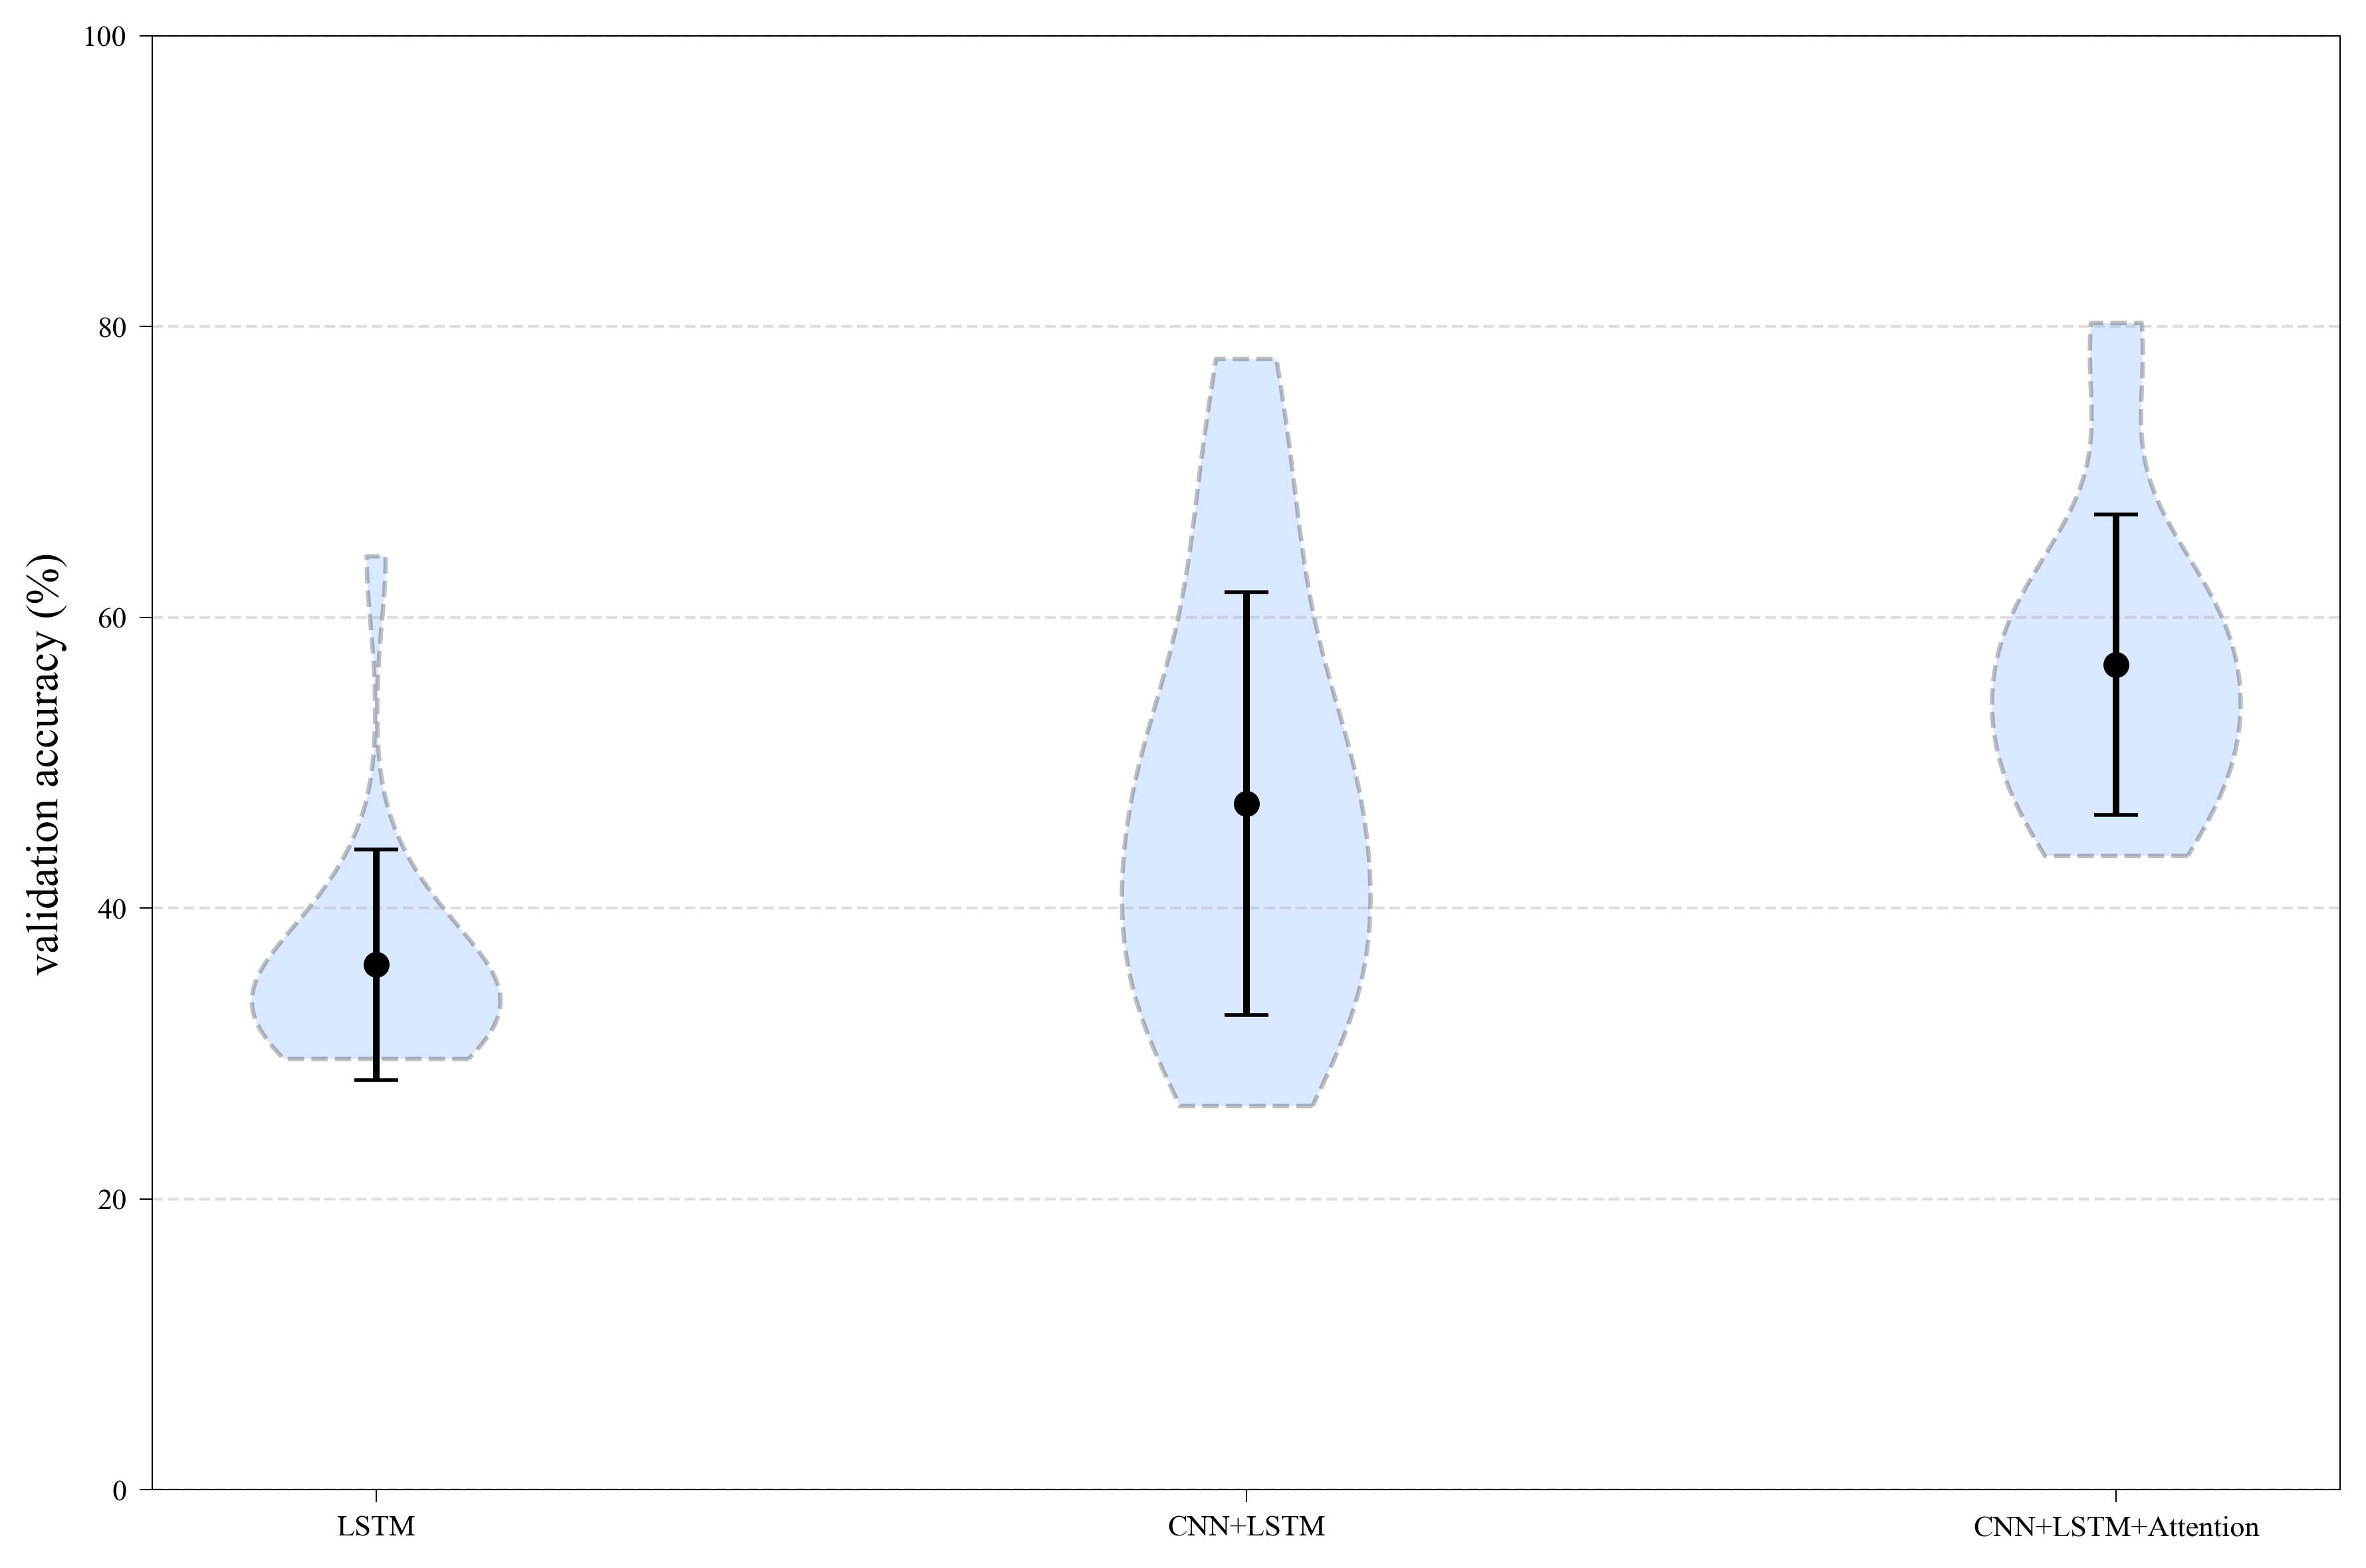

In [105]:
def plot_EEG_errorbar_violin(select_data, y_label, y_axis_range):

    networks = ['LSTM', 'CNN + LSTM', 'CNN + LSTM + Attention']
    models = ['LSTM', 'CNN+LSTM', 'CNN+LSTM+Attention']
    modalities = ['EEG']

    fig, ax = plt.subplots(figsize=(9, 6))

    positions = []
    colors = []

    group_spacing = 0.3
    box_spacing = 0.4

    pos = 0
    xticks = []
    xtick_labels = []

    modality_colors = ["#6BA4FF","#6BA4FF", "#6BA4FF"]

    # =========================
    # Build raincloud plot
    # =========================
    for net_idx, model in enumerate(models):
        start = pos


        values = np.array(select_data[model])

        positions.append(pos)
        colors.append(modality_colors[net_idx])

        # -------- CLOUD (half violin) --------
        parts = ax.violinplot(
            values,
            positions=[pos],
            widths=0.2,
            showmeans=False,
            showmedians=False,
            showextrema=False
        )

        for pc in parts['bodies']:
            pc.set_facecolor(modality_colors[net_idx])
            pc.set_edgecolor('black')
            pc.set_alpha(0.25)

            pc.set_linestyle('--')   # dashed outline
            pc.set_linewidth(1.2)

        xtick_labels.append(model)
        pos += box_spacing

        center = start + box_spacing
        xticks.append(center)

        pos += group_spacing

    # =========================
    # Error bars (mean ± std)
    # =========================
    acc_means = []
    acc_stds = []
    acc_positions = []

    for model in models:
        values = np.array(select_data[model])

        acc_means.append(np.mean(values))
        acc_stds.append(np.std(values, ddof=1))
        acc_positions.append(positions[len(acc_positions)])

    acc_means = np.array(acc_means)
    acc_stds = np.array(acc_stds)
    upper = np.minimum(acc_means + acc_stds, 100.0)
    lower = np.maximum(acc_means - acc_stds, 0.0)

    yerr = [acc_means - lower, upper - acc_means]

    for x, mean, low, up in zip(acc_positions, acc_means, yerr[0], yerr[1]):
        ax.errorbar(
            x,
            mean,
            yerr = [[low], [up]], 
            fmt='o',          # mean marker
            capsize=6,
            markersize=6,
            linewidth=1.8,
            color='black',
            zorder=4
        )

    # =========================
    # Labels & layout
    # =========================
    ax.set_ylabel(y_label, fontsize=12)

    # modality labels
    plt.xticks(positions, xtick_labels)

    plt.grid(axis='y', linestyle='--', alpha=0.4)

    yr = y_axis_range
    plt.ylim(yr[0], yr[1])
    plt.yticks(np.arange(yr[0], yr[1]+0.1, 20))

    fig.tight_layout()
    plt.savefig('EEG_subj_dependent_vacc.png', dpi = 400)
    plt.savefig('EEG_subj_dependent_vacc.pdf', dpi = 400)
    plt.show()


plot_EEG_errorbar_violin(select_data = subj_EEG_acc, y_label = 'validation accuracy (%)', y_axis_range=(0, 100))

In [20]:
for i, model in enumerate(networks):

    print(f"\n--- {model} ---")

    # Median
    median = box['medians'][i].get_ydata()[0]
    print(f"Median: {median:.3f}")

    # Box edges (Q1/Q3)
    q1 = box['boxes'][i].get_path().vertices[0, 1]
    q3 = box['boxes'][i].get_path().vertices[2, 1]

    print(f"Q1: {q1:.3f}")
    print(f"Q3: {q3:.3f}")

    # Whiskers
    whisker_low = box['whiskers'][2*i].get_ydata()[1]
    whisker_high = box['whiskers'][2*i+1].get_ydata()[1]

    print(f"Whisker low: {whisker_low:.3f}")
    print(f"Whisker high: {whisker_high:.3f}")

    # Outliers
    fliers = box['fliers'][i].get_ydata()
    print(f"Outliers: {fliers}")


--- LSTM ---
Median: 33.330
Q1: 33.330
Q3: 35.900
Whisker low: 29.630
Whisker high: 39.130
Outliers: [40.74 41.33 64.2 ]

--- CNN+LSTM ---
Median: 46.150
Q1: 35.800
Q3: 52.380
Whisker low: 26.390
Whisker high: 70.830
Outliers: [77.78]

--- CNN+LSTM+Attention ---
Median: 56.410
Q1: 50.000
Q3: 60.490
Whisker low: 43.590
Whisker high: 63.100
Outliers: [77.78 80.25]


## EEG band/regions analysis

### Load data -> compute PSD

In [ ]:
#==============================#
# Load dataset and compute PSD #
#==============================#
base_dir = Path().resolve().parents[0] / 'experiment/data'
print(base_dir)
subjects = [f'subject_{nr}' for nr in range(17)]

PSD_ins = DataAnalysis(fs = 125, base_dir = base_dir)
data = PSD_ins.inspect_frequency_ranges(subjects = subjects)

#======================================================================#
# Convert to matrices (subjects × classes × regions × bands) for ANOVA #
#======================================================================#
n_subjects = len(data)
n_classes = len(data[0])
REGIONS = ['prefrontal', 'frontal', 'central', 'temporal', 'parietal']
BANDS = ['delta', 'theta', 'alpha', 'beta', 'gamma']

all_mats = []

for subj_data in data:
    subj_mats = []

    for feat_dict in subj_data:                      # Extract PSD features (per channel x per band) for Class1 and then class2
        
        # Convert dict → matrix (channels × bands)
        mat = np.zeros((len(REGIONS), len(BANDS)))

        for i, ch in enumerate(REGIONS):
            for j, band in enumerate(BANDS):
                mat[i, j] = np.mean(feat_dict[ch][band])
        
        subj_mats.append(mat)
    
    all_mats.append(subj_mats)

all_mats = np.array(all_mats)           # Shape: (Subj, class, region, band)

S, C, R, B = all_mats.shape

### Statistics

In [ ]:
#========================#
# Convert to long format #
#========================#
rows = []

for s in range(n_subjects):
    for c in range(n_classes):
        for r in range(len(REGIONS)):
            for b in range(len(BANDS)):
                rows.append({
                    "subject": s,
                    "class": f"class_{c}",
                    "region": f"{REGIONS[r]}",
                    "band": f"{BANDS[b]}",
                    "condition": f"C{c}_R{r}_B{b}",
                    "psd": all_mats[s, c, r, b]
                })

df_long = pd.DataFrame(rows)

anova = AnovaRM(
    df_long,
    depvar="psd",
    subject="subject",
    within=["condition"]
)

res = anova.fit()
print(res)


#=========================#
# Post-hoc paired t-tests #
#=========================#
print("\n=== Post-hoc (paired t-tests, Holm corrected) ===")
# [rest, contract, release] -> [class 0, class 1, class 2]

class_pairs = list(combinations(range(n_classes), 2))

for c1, c2 in class_pairs:
    print(f"\n=== Comparing class {c1} vs {c2} ===")

    p_vals = []
    labels = []

    for r in range(R):
        for b in range(B):

            x = all_mats[:, c1, r, b]
            y = all_mats[:, c2, r, b]

            _, p = ttest_rel(x, y)

            p_vals.append(p)
            labels.append((r, b))

    reject, p_corr, _, _ = multipletests(p_vals, method='holm')

    for i, (r, b) in enumerate(labels):
        if reject[i]:
            print(f"{REGIONS[r]}, {BANDS[b]}: p={p_corr[i]:.4f}")

#===========#
# Cohen's d #
#===========#
# print("\n=== Cohen's d for significant differences ===")
# cohend = PSD_ins.compute_multiclass_separability(data_classes = data, REGIONS = REGIONS, BANDS = BANDS)
# print(cohend)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import shapiro

data = subj_EEG_acc['CNN+LSTM']['EEG']  # example

plt.figure()
sns.histplot(data, kde=True)

plt.title("Histogram + KDE")
plt.show()

stats.probplot(data, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

stat, p = shapiro(data)

print(f"Shapiro-Wilk: p={p:.4f}")

## Subject-independent across models for same modality

### Load data

In [12]:
sherpa_folders = ['SingleNet_LSTM_EEG', 'SingleNet_CNN+LSTM_EEG', 'SingleNet_CNN+LSTM+ATTENTION_EEG']
models_ids = ['model1', 'model2', 'model3']

bv_summary_vloss = {}
ba_summary_vloss = {}
bv_summary_acc = {}
ba_summary_acc = {}
bv_summary_vacc = {}
ba_summary_vacc = {}

for folder, model_id in zip(sherpa_folders, models_ids):
    bv_loss, ba_loss, bv_acc, ba_acc, bv_vacc, ba_vacc = extract_model_specs(sherpa_log_folder = folder)
    
    bv_summary_vloss[model_id] = bv_loss
    ba_summary_vloss[model_id] = ba_loss
    bv_summary_acc[model_id] = bv_acc
    ba_summary_acc[model_id] = ba_acc
    bv_summary_vacc[model_id] = bv_vacc
    ba_summary_vacc[model_id] = ba_vacc

print('Test accuracies :', 
      np.mean(bv_summary_vacc['model3']), np.std(bv_summary_vacc['model3']),
      np.mean(bv_summary_vacc['model2']), np.std(bv_summary_vacc['model2']))

Test accuracies : 50.59629275135261 11.459739775990494 52.54479581076832 8.297388226365507


### Statistics

In [13]:
losses = bv_summary_vloss

stat, p = friedmanchisquare(
    losses['model1'],
    losses['model2'],
    losses['model3']
)

print(f"Friedman test: stat={stat:.4f}, p={p:.4f}")

pairs = list(itertools.combinations(range(len(models_ids)), 2))

for i, j in pairs:
    i_id = models_ids[i]
    j_id = models_ids[j]
    stat, p = wilcoxon(losses[i_id], losses[j_id])
    print(f"Model {i_id} vs {j_id}: p={p:.4f}")

Friedman test: stat=12.2500, p=0.0022
Model model1 vs model2: p=0.0078
Model model1 vs model3: p=0.0078
Model model2 vs model3: p=0.7422


### Plot boxplot

In [ ]:
select_data = bv_summary_vloss

plt.figure(figsize=(8, 6))

data_to_plot = [select_data[m] for m in models_ids]

networks = ['LSTM', 'CNN + LSTM', 'CNN + LSTM + Attention']

# Create boxplot
box = plt.boxplot(
    data_to_plot,
    labels=networks,
    patch_artist=True,
    showmeans=False,
    medianprops=dict(color = 'black', linewidth=1.5),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=5, alpha=0.5),
)

# Soft, professional colors
colors = ["#6BA4FF", "#83FFA0", "#FF6469"]

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Add individual fold points (VERY important for transparency)
# for i, model in enumerate(models_ids):
#     y = select_data[model]
#     x = np.full(len(y), i + 1)  # all points exactly at the center
#     plt.scatter(x, y, alpha=0.7, s=30)

# Grid (subtle)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Labels
plt.xlabel("Models", fontsize=12)
plt.ylabel("Validation Loss", fontsize=12)
# plt.title("Validation Loss Distribution Across Models", fontsize=14, weight='bold')

# Clean layout
plt.tight_layout()
plt.savefig('subject-independent vloss distribution of EMG.png')
plt.show()

## Subject-independent across models and modality

In [5]:
#=======================================#
# Load data for each model and modality #
#=======================================#
sherpa_folders = ['SingleNet_LSTM_', 'SingleNet_CNN+LSTM_', 'SingleNet_CNN+LSTM+ATTENTION_']
sherpa_fusion = ['FusionNet_LSTM_norm2', 'FusionNet_CNN+LSTM_norm', 'FusionNet_CNN+LSTM+ATTENTION']

modality_ids = ['EEG', 'EMG']
models_ids = ['model1', 'model2', 'model3']


bv_summary_vloss = {}
ba_summary_vloss = {}
bv_summary_acc = {}
ba_summary_acc = {}
bv_summary_vacc = {}
ba_summary_vacc = {}

# SingleNet
for folder, model_id in zip(sherpa_folders, models_ids):
    bv_summary_vloss[model_id] = {}
    ba_summary_vloss[model_id] = {}
    bv_summary_acc[model_id] = {}
    ba_summary_acc[model_id] = {}
    bv_summary_vacc[model_id] = {}
    ba_summary_vacc[model_id] = {}

    for mod in modality_ids:
        model = folder + mod
        print(model)
        bv_loss, ba_loss, bv_acc, ba_acc, bv_vacc, ba_vacc = extract_model_specs(sherpa_log_folder = model)
        
        bv_summary_vloss[model_id][mod] = bv_loss
        ba_summary_vloss[model_id][mod] = ba_loss
        bv_summary_acc[model_id][mod] = bv_acc
        ba_summary_acc[model_id][mod] = ba_acc
        bv_summary_vacc[model_id][mod] = bv_vacc
        ba_summary_vacc[model_id][mod] = ba_vacc

# Fusion
mod = 'fusion'
for model, model_id in zip(sherpa_fusion, models_ids):
        bv_loss, ba_loss, bv_acc, ba_acc, bv_vacc, ba_vacc = extract_model_specs(sherpa_log_folder = model)
        
        bv_summary_vloss[model_id][mod] = bv_loss
        ba_summary_vloss[model_id][mod] = ba_loss
        bv_summary_acc[model_id][mod] = bv_acc
        ba_summary_acc[model_id][mod] = ba_acc
        bv_summary_vacc[model_id][mod] = bv_vacc
        ba_summary_vacc[model_id][mod] = ba_vacc

SingleNet_LSTM_EEG
SingleNet_LSTM_EMG
SingleNet_CNN+LSTM_EEG
SingleNet_CNN+LSTM_EMG
SingleNet_CNN+LSTM+ATTENTION_EEG
SingleNet_CNN+LSTM+ATTENTION_EMG


In [6]:

print('M1 EEG: Mean:', np.mean(bv_summary_vloss['model1']['EEG']), 'std', np.std(bv_summary_vloss['model1']['EEG']))
print('M2 EEG: Mean:', np.mean(bv_summary_vloss['model2']['EEG']), 'std', np.std(bv_summary_vloss['model2']['EEG']))
print('M3 EEG: Mean:', np.mean(bv_summary_vloss['model3']['EEG']), 'std', np.std(bv_summary_vloss['model3']['EEG']))
print()
print('M1 EMG: Mean:', np.mean(bv_summary_vloss['model1']['EMG']), 'std', np.std(bv_summary_vloss['model1']['EMG']))
print('M2 EMG: Mean:', np.mean(bv_summary_vloss['model2']['EMG']), 'std', np.std(bv_summary_vloss['model2']['EMG']))
print('M3 EMG: Mean:', np.mean(bv_summary_vloss['model3']['EMG']), 'std', np.std(bv_summary_vloss['model3']['EMG']))
print()
print('M1 EMG: Mean:', np.mean(bv_summary_vloss['model1']['fusion']), 'std', np.std(bv_summary_vloss['model1']['fusion']))
print('M2 EMG: Mean:', np.mean(bv_summary_vloss['model2']['fusion']), 'std', np.std(bv_summary_vloss['model2']['fusion']))
print('M3 EMG: Mean:', np.mean(bv_summary_vloss['model3']['fusion']), 'std', np.std(bv_summary_vloss['model3']['fusion']))

# ba_summary_vloss['model2']['EEG'], bv_summary_vloss['model3']['EEG']
# bv_summary_vloss['model3']['EEG'] = ba_summary_vloss['model3']['EEG']
print('\nEEG test accuracy\n')
print(np.mean(bv_summary_vacc['model1']['EMG']), np.std(bv_summary_vacc['model1']['EMG']),
      np.mean(bv_summary_vacc['model2']['EMG']), np.std(bv_summary_vacc['model2']['EMG']),
      np.mean(bv_summary_vacc['model3']['EMG']), np.std(bv_summary_vacc['model3']['EMG']),)
print()
bv_summary_acc['model1']['fusion'], bv_summary_acc['model2']['fusion'], bv_summary_acc['model3']['fusion']

M1 EEG: Mean: 1.081844995315704 std 0.013893050133880801
M2 EEG: Mean: 0.9517070236224501 std 0.1372551359120455
M3 EEG: Mean: 0.9417090324374536 std 0.1519629496650754

M1 EMG: Mean: 0.33150772728666217 std 0.3685960564055516
M2 EMG: Mean: 0.2072239235692414 std 0.3312689520492401
M3 EMG: Mean: 0.20831863897533026 std 0.26522772278816914

M1 EMG: Mean: 1.007535722757619 std 0.5378361541134646
M2 EMG: Mean: 0.6071409307657545 std 0.3687130496193282
M3 EMG: Mean: 0.6325556994086413 std 0.47271776525382875

EEG test accuracy

89.18807349288052 16.025145446572616 94.41083447476922 8.623715831604304 93.99065916799188 7.4149965792521



(98.93842887473461, 98.93842887473461, 99.15074309978769)

### Statistics

In [95]:
losses = bv_summary_vacc
modality_ids = ['EEG', 'EMG', 'fusion']

# Compare models within each modality
print('#-------------Compare models within each modality-------------#\n')
for modality in modality_ids:
    stat, p = friedmanchisquare(
        losses[models_ids[0]][modality],
        losses[models_ids[1]][modality],
        losses[models_ids[2]][modality]
    )
    print(f"Modality {modality}: p={p:.4f}, stat={stat:.4f}")

print('\n#-------------Corresponding wilcoxon-------------#')
for modality in range(len(modality_ids)):
    print(f"\nPost-hoc for modality {modality_ids[modality]}")
    
    for i, j in itertools.combinations(range(len(models_ids)), 2):
        i_id = models_ids[i]
        j_id = models_ids[j]

        stat, p = wilcoxon(
            losses[i_id][modality_ids[modality]],
            losses[j_id][modality_ids[modality]],
            #method = 'approx'
        )
        print(f"Model {i} vs {j}: p={p:.4f}, stat: {stat:.8f}")

print('\n#-------------Compare modalities within each model-------------#\n')
# Compare modalities within each model - Need of 3 modalities
for model in models_ids:
    stat, p = friedmanchisquare(
        losses[model][modality_ids[0]],
        losses[model][modality_ids[1]],
        losses[model][modality_ids[2]]
    )
    print(f"Model {model}: p={p:.4f}, stat: {stat:.8f}")

print('\n#-------------Corresponding wilcoxon-------------#')
for model_idx in range(len(models_ids)):
    print(f"\nPost-hoc for models {models_ids[model_idx]}")
    
    for i, j in itertools.combinations(range(len(modality_ids)), 2):
        i_id = modality_ids[i]
        j_id = modality_ids[j]

        stat, p = wilcoxon(
            losses[models_ids[model_idx]][i_id],
            losses[models_ids[model_idx]][j_id]
        )
        print(f"Modality {i_id} vs {j_id}: p={p:.4f}, stat: {stat:.8f}")

# for model in models_ids:
#     stat, p = wilcoxon(
#         losses[model][modality_ids[0]],
#         losses[model][modality_ids[1]]
#     )
#     print(f"Model {model}: p={p:.4f}, stat={stat:.4f}")

''' for report
results ending
Additionally, significant differences between modalities were observed for all models (p ≤ 0.0156),
indicating that modality choice has a consistent impact on performance.

Conclusion
The results show a clear separation between modalities, 
with EMG yielding substantially lower validation loss than EEG across all models. 
Model differences are primarily observed in the EMG modality, 
where CNN+LSTM achieves the lowest median loss and highest consistency. 
In contrast, the LSTM model exhibits both higher loss and greater variability. 
The addition of attention does not provide a clear benefit over the CNN+LSTM architecture.
'''

#-------------Compare models within each modality-------------#

Modality EEG: p=0.0015, stat=13.0000
Modality EMG: p=0.0027, stat=11.8065
Modality fusion: p=0.0015, stat=13.0000

#-------------Corresponding wilcoxon-------------#

Post-hoc for modality EEG
Model 0 vs 1: p=0.0078, stat: 0.00000000
Model 0 vs 2: p=0.0078, stat: 0.00000000
Model 1 vs 2: p=0.3828, stat: 11.00000000

Post-hoc for modality EMG
Model 0 vs 1: p=0.0078, stat: 0.00000000
Model 0 vs 2: p=0.0234, stat: 2.00000000
Model 1 vs 2: p=0.2367, stat: 7.00000000

Post-hoc for modality fusion
Model 0 vs 1: p=0.0078, stat: 0.00000000
Model 0 vs 2: p=0.0078, stat: 0.00000000
Model 1 vs 2: p=0.2500, stat: 9.00000000

#-------------Compare modalities within each model-------------#

Model model1: p=0.0046, stat: 10.75000000
Model model2: p=0.0008, stat: 14.25000000
Model model3: p=0.0015, stat: 13.00000000

#-------------Corresponding wilcoxon-------------#

Post-hoc for models model1
Modality EEG vs EMG: p=0.0078, stat: 0.000

c:\Users\Bruger\Documents\hybrid_bci\.venv\Lib\site-packages\scipy\stats\_morestats.py:4088: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
c:\Users\Bruger\Documents\hybrid_bci\.venv\Lib\site-packages\scipy\stats\_morestats.py:4102: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")


' for report\nresults ending\nAdditionally, significant differences between modalities were observed for all models (p ≤ 0.0156),\nindicating that modality choice has a consistent impact on performance.\n\nConclusion\nThe results show a clear separation between modalities, \nwith EMG yielding substantially lower validation loss than EEG across all models. \nModel differences are primarily observed in the EMG modality, \nwhere CNN+LSTM achieves the lowest median loss and highest consistency. \nIn contrast, the LSTM model exhibits both higher loss and greater variability. \nThe addition of attention does not provide a clear benefit over the CNN+LSTM architecture.\n'

### Plot Boxplot

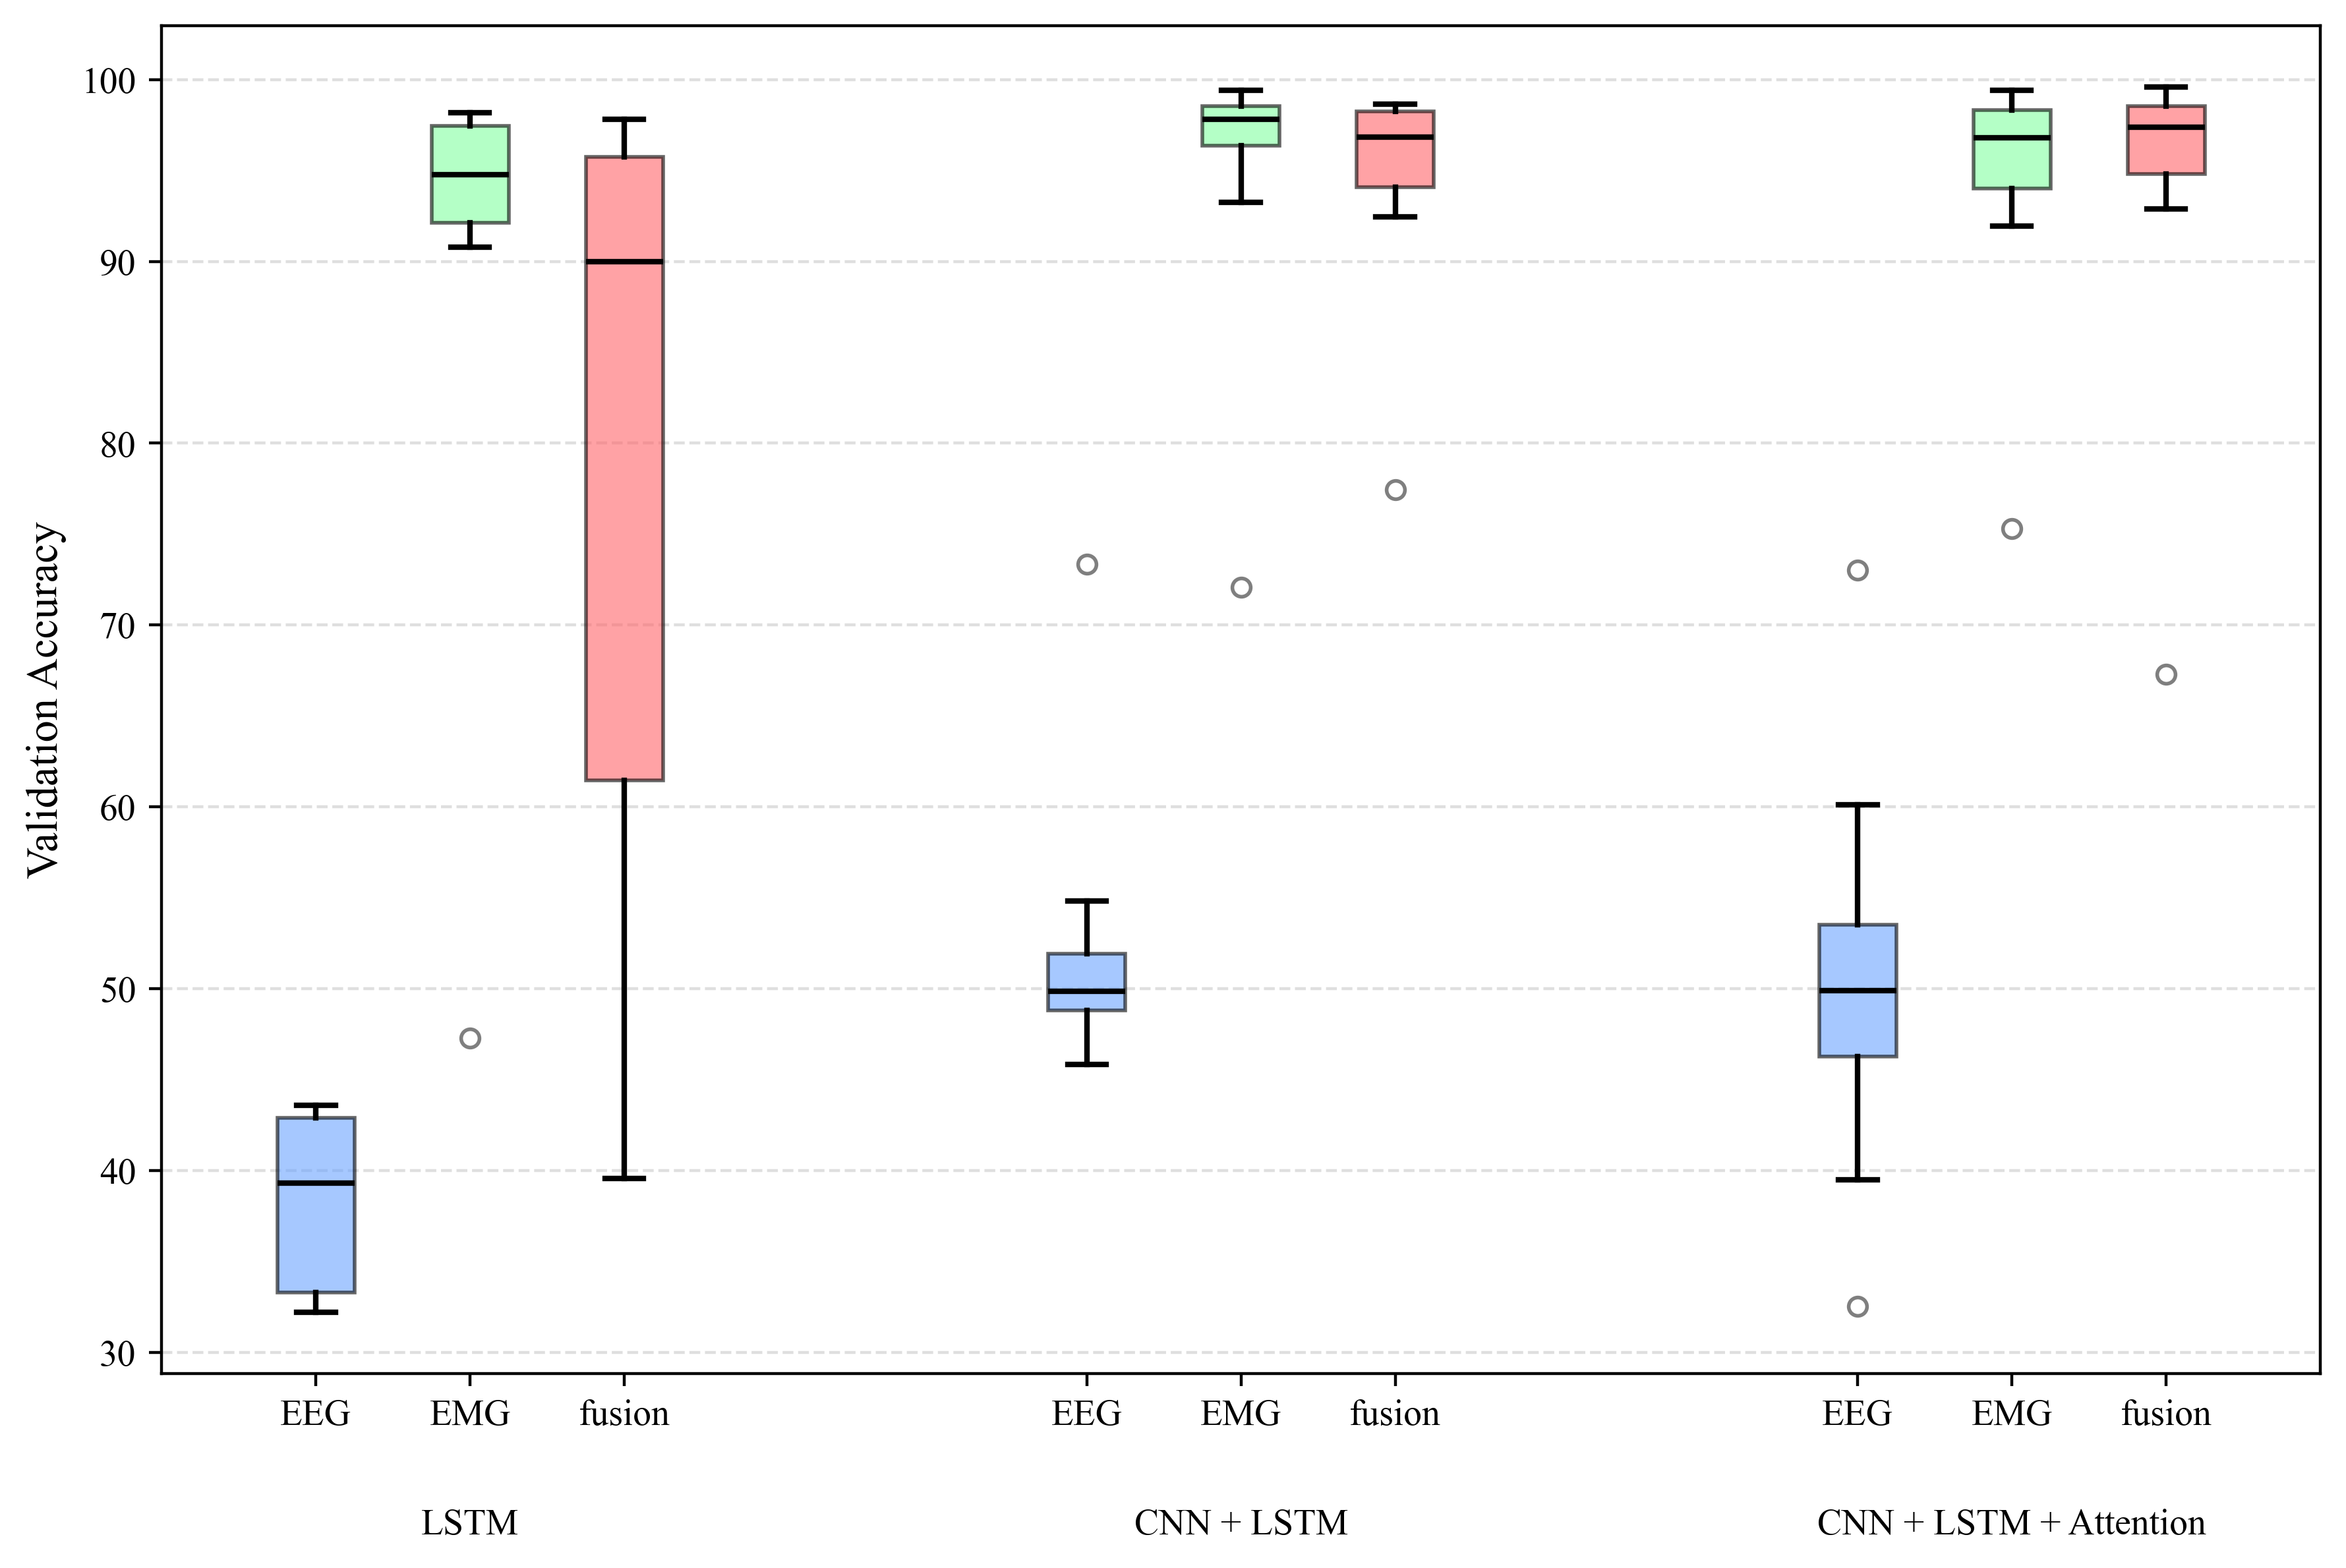

In [96]:
select_data = bv_summary_vacc

networks = ['LSTM', 'CNN + LSTM', 'CNN + LSTM + Attention']
models = ['model1', 'model2', 'model3']
modalities = ['EEG', 'EMG', 'fusion']

plt.figure(figsize=(9, 6))

positions = []
data_to_plot = []
colors = []

# --- Layout parameters ---
group_spacing = 1.0
box_spacing = 0.5

pos = 0
xticks = []
xtick_labels = []

# Color per modality (consistent across models)
modality_colors = {
    'EEG': "#6BA4FF",
    'EMG': "#83FFA0",
    'fusion': "#FF6469"
}

# --- Build positions + data ---
for model in models:
    start = pos
    
    for mod, net in zip(modalities, networks):
        positions.append(pos)
        data_to_plot.append(select_data[model][mod])
        colors.append(modality_colors[mod])
        
        xtick_labels.append(mod)
        pos += box_spacing
    
    center = start + box_spacing
    xticks.append(center)
    
    pos += group_spacing

# --- Plot ---
box = plt.boxplot(
    data_to_plot,
    positions=positions,
    widths=0.25,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=1.5),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=5, alpha=0.5)
)

# --- Apply colors ---
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# --- Grid ---
plt.grid(axis='y', linestyle='--', alpha=0.4)

# --- X ticks (modalities) ---
plt.xticks(positions, xtick_labels)

# --- Model labels underneath ---
for center, model in zip(xticks, networks):
    plt.text(
    center,
    -0.1,  # below axis
    model,
    ha='center',
    va='top',
    transform=plt.gca().get_xaxis_transform()
)

# --- Labels ---
plt.ylabel("Validation Accuracy", fontsize=12)
plt.xlabel("")

plt.tight_layout()
# plt.savefig('grouped_boxplot_modalities.png', dpi=400, bbox_inches='tight')
plt.show()

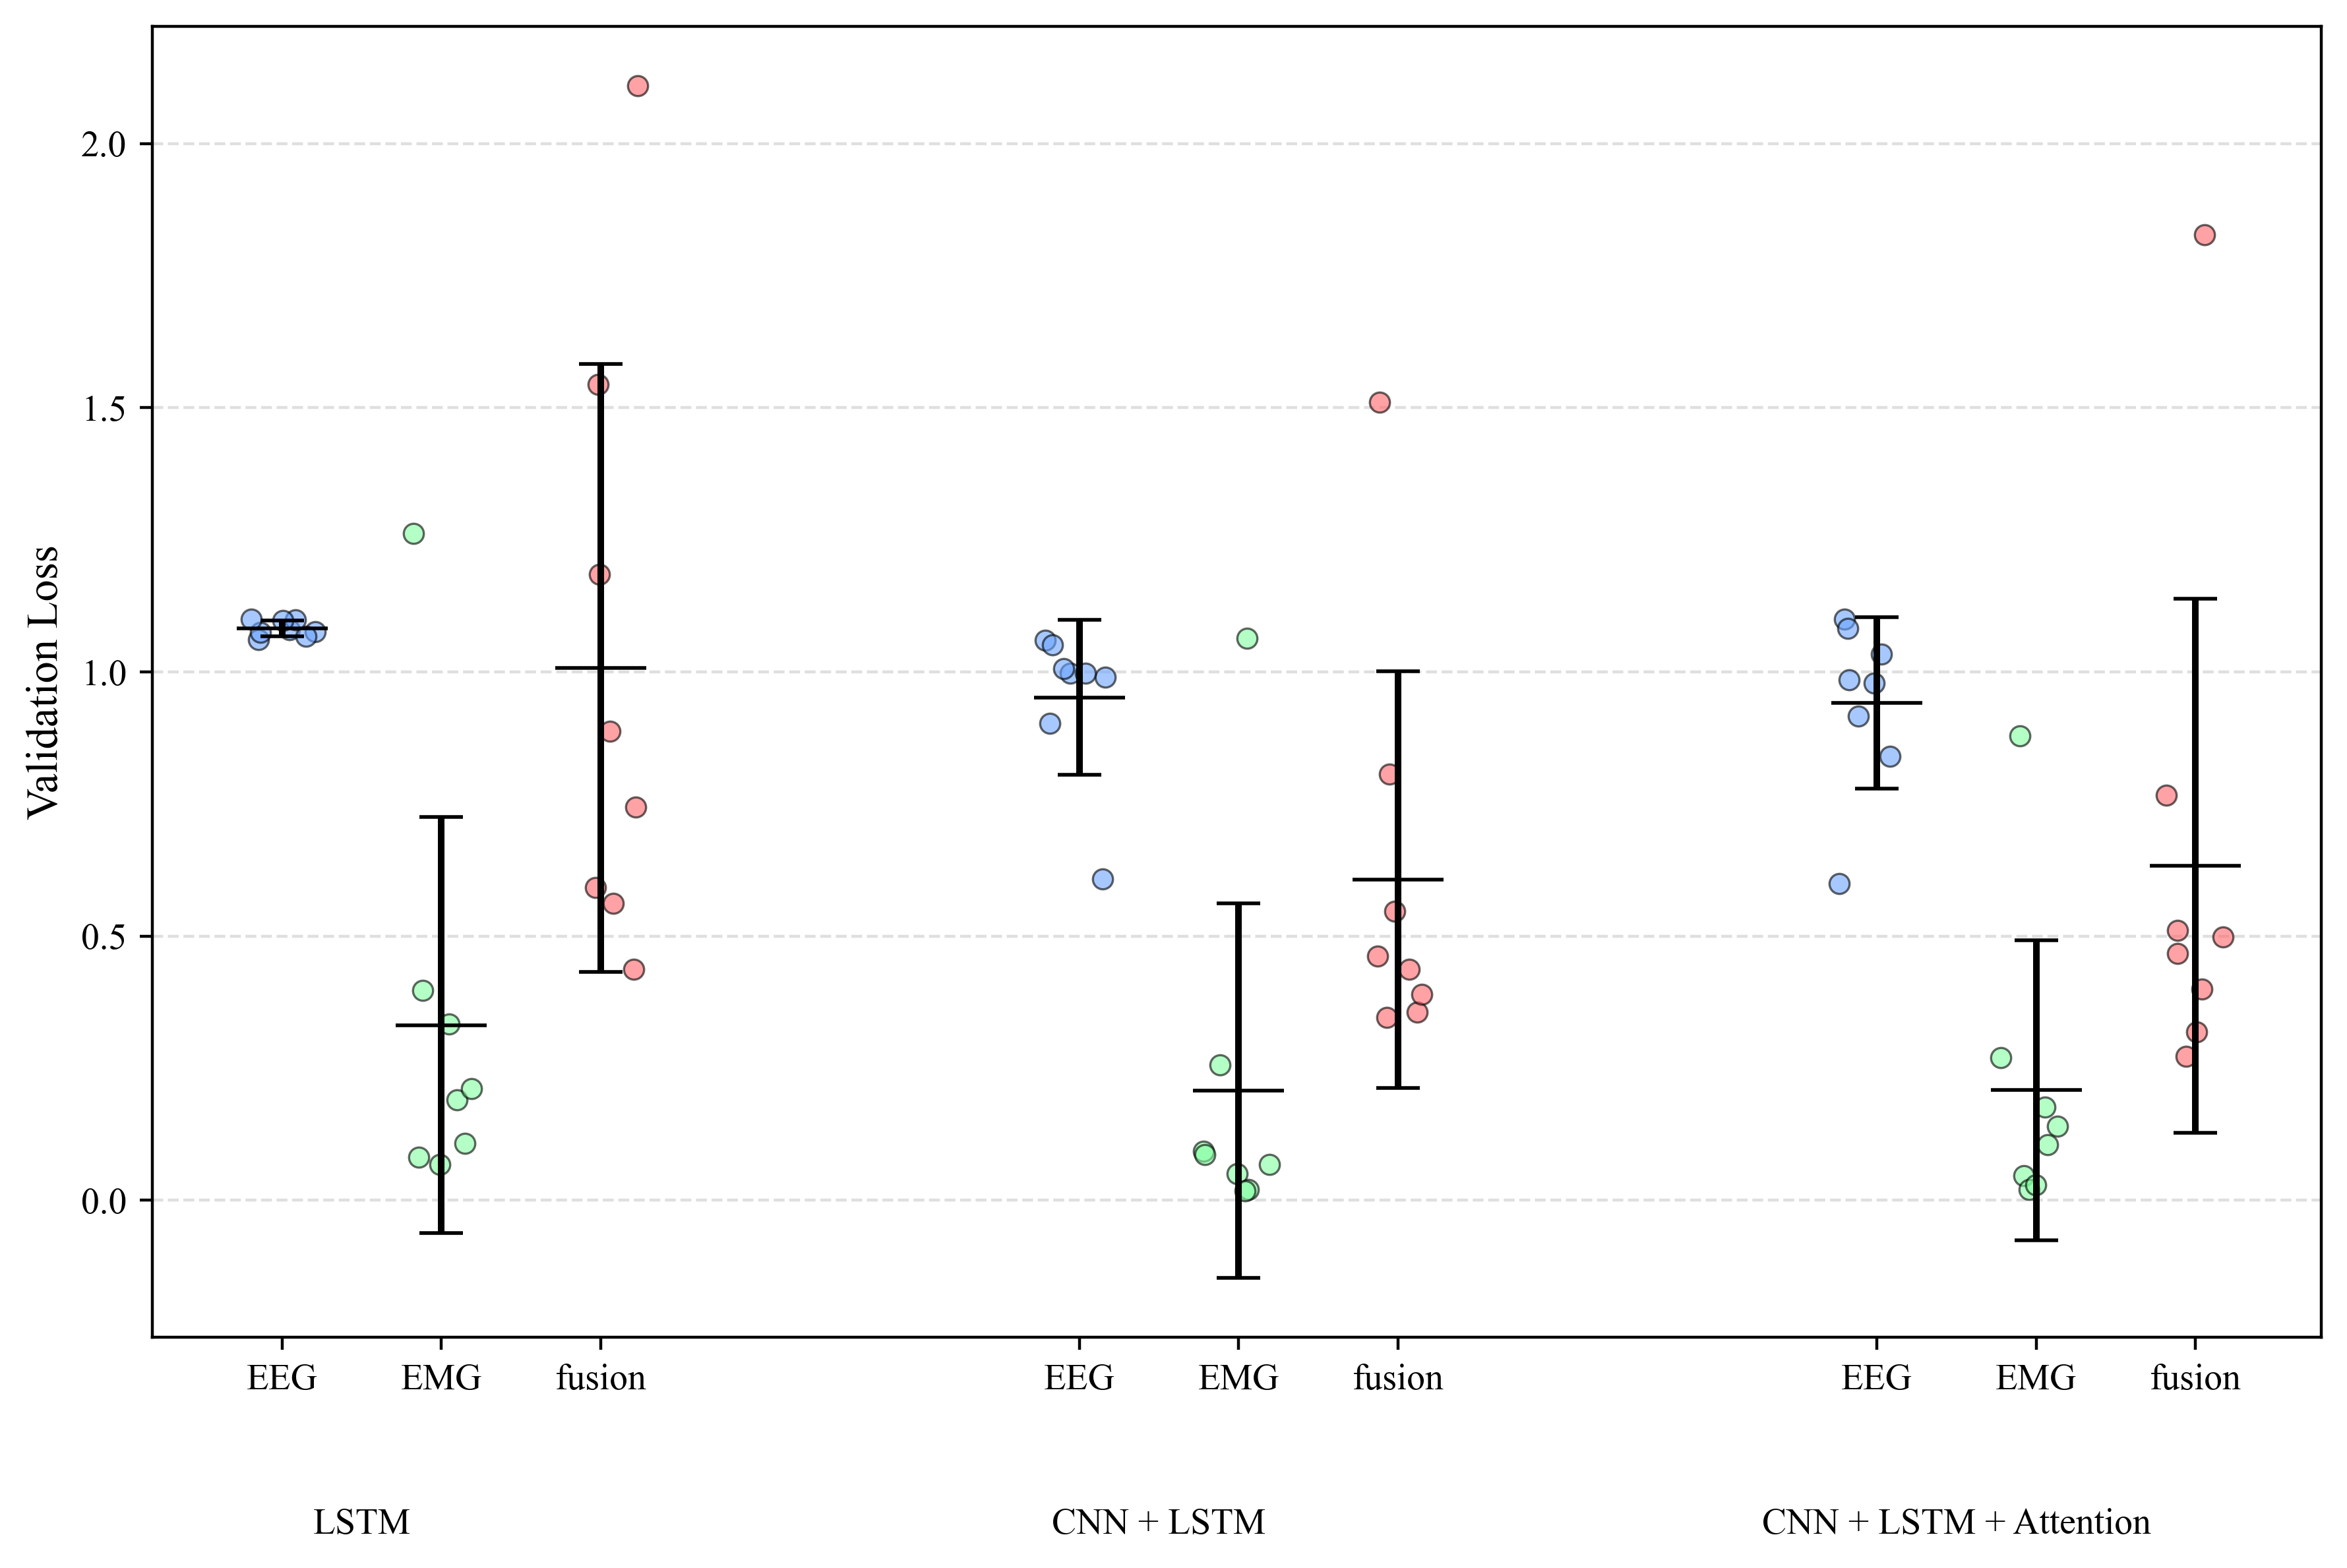

In [97]:
select_acc  = bv_summary_vloss   # <-- your validation accuracy dict

networks = ['LSTM', 'CNN + LSTM', 'CNN + LSTM + Attention']
models = ['model1', 'model2', 'model3']
modalities = ['EEG', 'EMG', 'fusion']

fig, ax = plt.subplots(figsize=(9, 6))

positions = []
data_to_plot = []
colors = []

group_spacing = 1.0
box_spacing = 0.5

pos = 0
xticks = []
xtick_labels = []

modality_colors = {
    'EEG': "#6BA4FF",
    'EMG': "#83FFA0",
    'fusion': "#FF6469"
}

# --- Build positions + loss data ---
for model in models:
    start = pos

    for mod in modalities:
        values = np.array(select_acc[model][mod])

        positions.append(pos)
        colors.append(modality_colors[mod])

        # --- Scatter raw samples (jittered) ---
        jitter = np.random.uniform(-0.12, 0.12, size=len(values))
        ax.scatter(
            np.full(len(values), pos) + jitter,
            values,
            facecolor=modality_colors[mod],   # fill color
            edgecolor='black',                # edge color
            linewidth=0.6,
            alpha=0.6,
            s=30,
            zorder=3,
        )

        xtick_labels.append(mod)
        pos += box_spacing

    center = start + box_spacing / 2
    xticks.append(center)

    pos += group_spacing

acc_means = []
acc_stds = []
acc_colors = []

for model in models:
    for mod in modalities:
        acc_values = np.array(select_acc[model][mod])

        acc_means.append(np.mean(acc_values))
        acc_stds.append(np.std(acc_values, ddof=1))
        acc_colors.append(modality_colors[mod])   # <-- match color

# Small horizontal offset so error bars appear next to boxes
acc_positions = np.array(positions)

acc_means = np.array(acc_means)
acc_stds = np.array(acc_stds)
upper = np.minimum(acc_means + acc_stds, 100.0)
lower = np.maximum(acc_means - acc_stds, 0.0)


yerr = [acc_means - lower, upper - acc_means]

kkk = 0
for x, mean, err, color in zip(acc_positions, acc_means, acc_stds, acc_colors):

    ax.errorbar(
        x,
        mean,
        yerr= err, #[[err[0]], [err[1]]],
        fmt='_',
        capsize=6,
        markersize=25,
        linewidth=1.8,
        color='black',
        zorder = 4
    )


ax.set_ylabel("Validation Loss", fontsize=12)

# --- X ticks (modalities) ---
plt.xticks(positions, xtick_labels)

# --- Model labels underneath ---
for center, net in zip(xticks, networks):
    ax.text(
        center,
        -0.13,
        net,
        ha='center',
        va='top',
        transform=ax.get_xaxis_transform()
    )


fig.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()


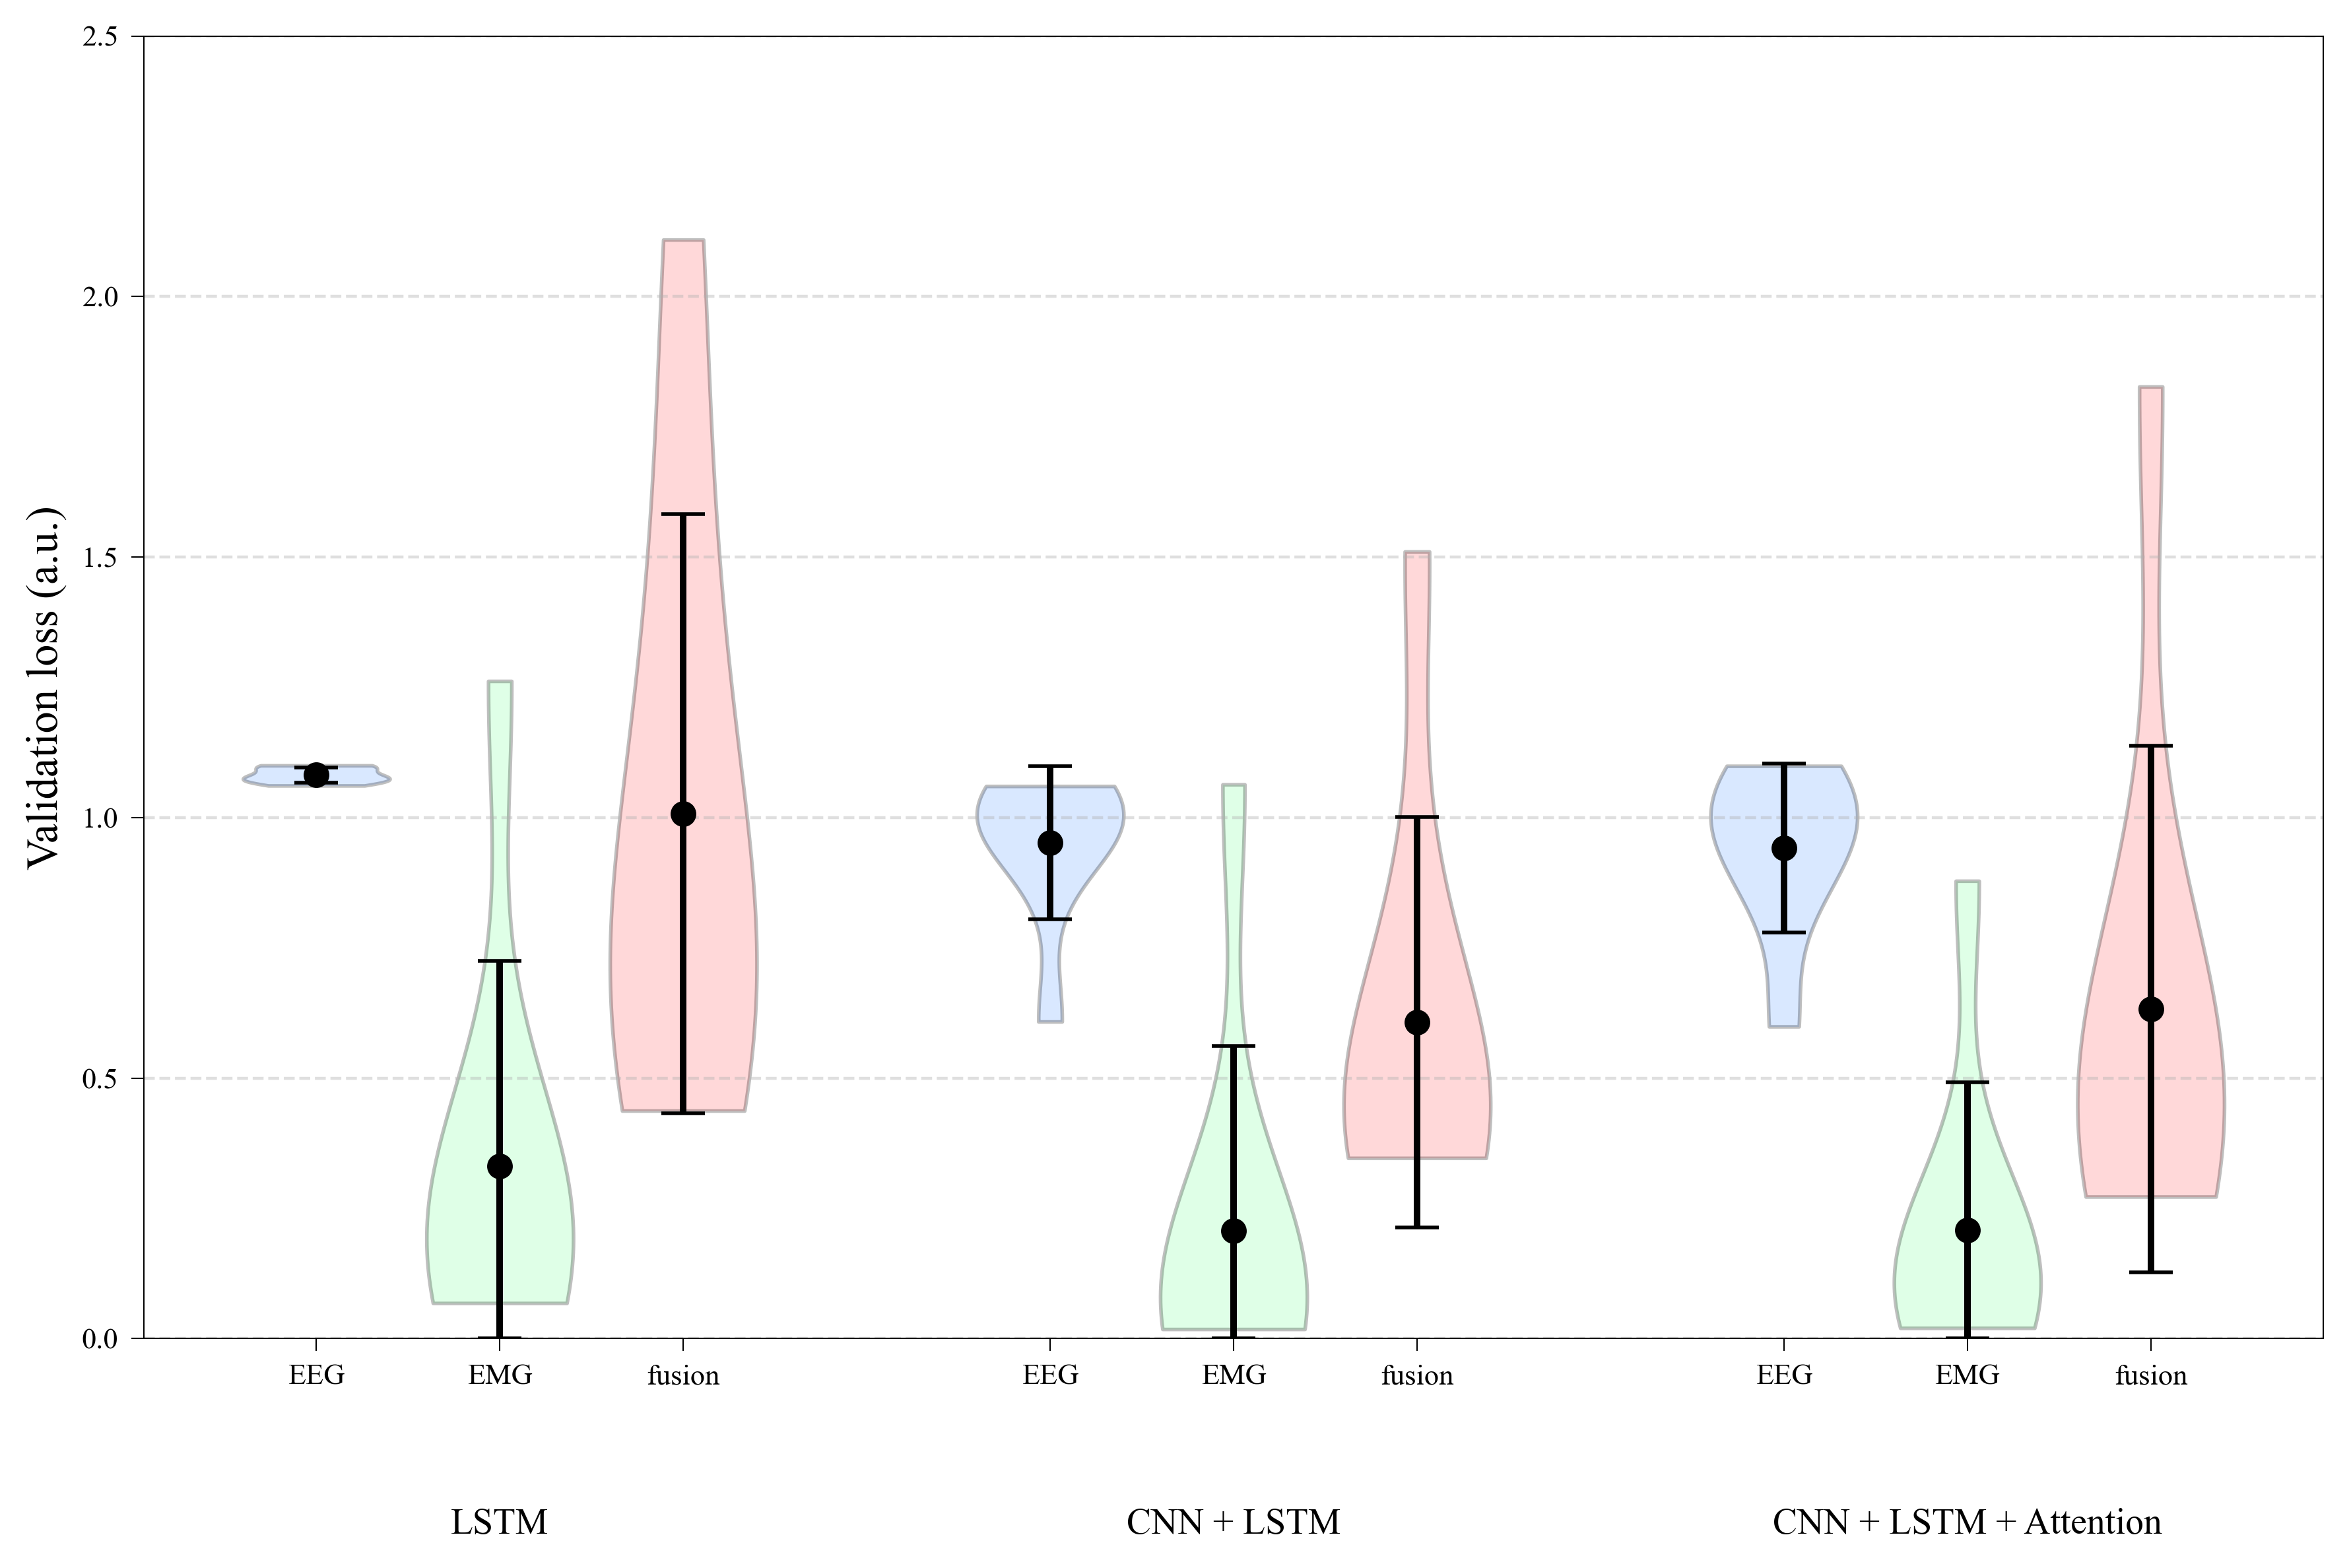

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import itertools

# --- Your data ---
def plot_errorbar_violin(select_data, y_label, y_axis_range):

    networks = ['LSTM', 'CNN + LSTM', 'CNN + LSTM + Attention']
    models = ['model1', 'model2', 'model3']
    modalities = ['EEG', 'EMG', 'fusion']

    fig, ax = plt.subplots(figsize=(9, 6))

    positions = []
    colors = []

    group_spacing = 0.5
    box_spacing = 0.5

    pos = 0
    xticks = []
    xtick_labels = []

    modality_colors = {
        'EEG': "#6BA4FF",
        'EMG': "#83FFA0",
        'fusion': "#FF6469"
    }

    # =========================
    # Build raincloud plot
    # =========================
    for model in models:
        start = pos

        for mod in modalities:
            values = np.array(select_data[model][mod])

            positions.append(pos)
            colors.append(modality_colors[mod])

            # -------- CLOUD (half violin) --------
            parts = ax.violinplot(
                values,
                positions=[pos],
                widths=0.4,
                showmeans=False,
                showmedians=False,
                showextrema=False
            )

            for pc in parts['bodies']:
                pc.set_facecolor(modality_colors[mod])
                pc.set_edgecolor('black')
                pc.set_alpha(0.25)

                # Make HALF violin (left side only)
                # verts = pc.get_paths()[0].vertices
                # center = np.mean(verts[:, 0])
                # verts[:, 0] = np.minimum(verts[:, 0], center)

            # -------- RAIN (scatter) --------
            # jitter = np.random.uniform(0.02, 0.12, size=len(values))  # push right
            # ax.scatter(
            #     np.full(len(values), pos) + jitter,
            #     values,
            #     facecolor=modality_colors[mod],
            #     edgecolor='black',
            #     linewidth=0.6,
            #     alpha=0.6,
            #     s=30,
            #     zorder=3,
            # )

            xtick_labels.append(mod)
            pos += box_spacing

        center = start + box_spacing
        xticks.append(center)

        pos += group_spacing

    # =========================
    # Error bars (mean ± std)
    # =========================
    acc_means = []
    acc_stds = []
    acc_positions = []

    for model in models:
        for mod in modalities:
            values = np.array(select_data[model][mod])

            acc_means.append(np.mean(values))
            acc_stds.append(np.std(values, ddof=1))
            acc_positions.append(positions[len(acc_positions)])

    acc_means = np.array(acc_means)
    acc_stds = np.array(acc_stds)
    upper = np.minimum(acc_means + acc_stds, 100.0)
    lower = np.maximum(acc_means - acc_stds, 0.0)

    yerr = [acc_means - lower, upper - acc_means]

    for x, mean, low, up in zip(acc_positions, acc_means, yerr[0], yerr[1]):
        ax.errorbar(
            x,
            mean,
            yerr = [[low], [up]], 
            fmt='o',          # mean marker
            capsize=6,
            markersize=6,
            linewidth=1.8,
            color='black',
            zorder=4
        )

    # =========================
    # Labels & layout
    # =========================
    ax.set_ylabel(y_label, fontsize=12)

    # modality labels
    plt.xticks(positions, xtick_labels)

    # model labels underneath
    for center, net in zip(xticks, networks):
        ax.text(
            center,
            -0.13,
            net,
            ha='center',
            va='top',
            transform=ax.get_xaxis_transform()
        )

    plt.grid(axis='y', linestyle='--', alpha=0.4)

    yr = y_axis_range
    plt.ylim(yr[0], yr[1])
    plt.yticks(np.arange(yr[0], yr[1]+0.1, 0.5))
    # plt.yticks(np.arange(yr[0], yr[1]+0.1, 20))

    fig.tight_layout()
    # plt.savefig('subj_independent_vloss.png', dpi = 400)
    # plt.savefig('subj_independent_vloss.pdf', dpi = 400)
    plt.show()

# --- Your data ---
def plot_EMG_errorbar_violin(select_data, y_label, y_axis_range):

    networks = ['LSTM', 'CNN + LSTM', 'CNN + LSTM + Attention']
    models = ['model1', 'model2', 'model3']
    modalities = ['EMG']

    fig, ax = plt.subplots(figsize=(9, 6))

    positions = []
    colors = []

    group_spacing = 0.3
    box_spacing = 0.4

    pos = 0
    xticks = []
    xtick_labels = []

    modality_colors = ["#6BA4FF", "#83FFA0", "#FF6469"]

    # =========================
    # Build raincloud plot
    # =========================
    for net_idx, model in enumerate(models):
        start = pos

        for mod in modalities:
            values = np.array(select_data[model][mod])

            positions.append(pos)
            colors.append(modality_colors[net_idx])

            # -------- CLOUD (half violin) --------
            parts = ax.violinplot(
                values,
                positions=[pos],
                widths=0.2,
                showmeans=False,
                showmedians=False,
                showextrema=False
            )

            for pc in parts['bodies']:
                pc.set_facecolor(modality_colors[net_idx])
                pc.set_edgecolor('black')
                pc.set_alpha(0.25)

            xtick_labels.append(mod)
            pos += box_spacing

        center = start + box_spacing
        xticks.append(center)

        pos += group_spacing

    # =========================
    # Error bars (mean ± std)
    # =========================
    acc_means = []
    acc_stds = []
    acc_positions = []

    for model in models:
        for mod in modalities:
            values = np.array(select_data[model][mod])

            acc_means.append(np.mean(values))
            acc_stds.append(np.std(values, ddof=1))
            acc_positions.append(positions[len(acc_positions)])

    acc_means = np.array(acc_means)
    acc_stds = np.array(acc_stds)
    upper = np.minimum(acc_means + acc_stds, 100.0)
    lower = np.maximum(acc_means - acc_stds, 0.0)

    yerr = [acc_means - lower, upper - acc_means]

    for x, mean, low, up in zip(acc_positions, acc_means, yerr[0], yerr[1]):
        ax.errorbar(
            x,
            mean,
            yerr = [[low], [up]], 
            fmt='o',          # mean marker
            capsize=6,
            markersize=6,
            linewidth=1.8,
            color='black',
            zorder=4
        )

    # =========================
    # Labels & layout
    # =========================
    ax.set_ylabel(y_label, fontsize=12)

    # modality labels
    plt.xticks(positions, xtick_labels)

    # model labels underneath
    for center, net in zip(xticks, networks):
        ax.text(
            center,
            -0.13,
            net,
            ha='center',
            va='top',
            transform=ax.get_xaxis_transform()
        )

    plt.grid(axis='y', linestyle='--', alpha=0.4)

    yr = y_axis_range
    plt.ylim(yr[0], yr[1])
    # plt.yticks(np.arange(0, yr[1]+0.01, 0.25))

    fig.tight_layout()
    plt.savefig('subj_independent_vacc.png', dpi = 400)
    plt.savefig('subj_independent_vacc.pdf', dpi = 400)
    plt.show()

plot_errorbar_violin(select_data = bv_summary_vloss, y_label = 'Validation loss (a.u.)', y_axis_range = [0, 2.5])
# plot_errorbar_violin(select_data = bv_summary_vacc, y_label = 'Validation accuracy (%)', y_axis_range = [0, 100])
# plot_EMG_errorbar_violin(select_data = bv_summary_vacc, y_label = 'Validation accuracy (%)', y_axis_range = [40, 100.1])
# plot_EMG_errorbar_raincloud(select_data = bv_summary_vacc, y_label = 'Validation loss (a.u.)', y_axis_range = [-0.01, 100.1])

In [101]:
20/(100-0) * 2.5

0.5

## Metabolic Cost

### Functions

In [104]:
from src.utilities.preprocessing import Filtering, EMG_preprocessing
from src.utilities.load_and_visualize_data import load_datasets

def _compute_mvc(base_dir, fs, EMG_ins, EMG_config_dict):
    baseline_rest = pd.read_csv(f'{base_dir}/MVC_baseline_noise.csv').to_numpy()
    baseline_contract = pd.read_csv(f'{base_dir}/MVC_baseline_mvc.csv').to_numpy()

    # print('Baseline', np.mean(baseline_rest, axis=0))
    # print('peak', np.max(baseline_contract, axis=0))

    EMG_filter_ins = Filtering(fs = fs)    

    data_container = {}    
    
    for segment, data in zip(['rest', 'contract'], [baseline_rest, baseline_contract]):
        EMG_notch = EMG_filter_ins.notch(data, cutoff=50, Q=30)
        EMG_bandpass, _ = EMG_filter_ins.butter_bandpass(EMG_notch, lowcut = EMG_ins.lowcut, highcut = EMG_ins.highcut, order=4)

        EMG_hampel = EMG_filter_ins.hampel_filter(x = EMG_bandpass, window_size = EMG_config_dict['hampel_windowsize'], n_sigmas = EMG_config_dict['hampel_sigma'])

        RMS = EMG_ins.rms_conv(signal = EMG_hampel, window_size = EMG_config_dict['rms_windowsize'], step_size = EMG_config_dict['rms_stepsize'])

        data_container[segment] = RMS
    
    baseline = np.mean(data_container['rest'], axis = 0)          # Baseline noise across channels
    peak = np.max(data_container['contract'], axis = 0)           # Max peak across 
    
    # print('Baseline', baseline)
    # print('peak', peak)
    
    return baseline, peak

def _mvc_normalization(emg, baseline_noise, baseline_peak):
    return (emg - baseline_noise) / (baseline_peak - baseline_noise)

def load_dataset_for_metabolic_cost(experiment_folder_name, motion_list, RMS_FREQ):
    #===========#
    # Load data #
    #===========#
    EMG_FREQ = 2000
    EMG_HIGHCUT = 450
    EMG_LOWCUT = 20        # 32
    TRIM_PERIOD = 3
    RMS_SAMPLING_WINDOW = 500           # 250 ms
    RMS_WINDOW_STEPSIZE = 50            # 25 ms (90 % overlap)
    HAMPEL_WINDOWSIZE = 100
    RMS_FREQ = int(EMG_FREQ / RMS_WINDOW_STEPSIZE)
    HAMPEL_SIGMA = 2
    EMG_CONFIG_DICT = {
        'rms_windowsize' : RMS_SAMPLING_WINDOW,
        'rms_stepsize' : RMS_WINDOW_STEPSIZE,
        'hampel_windowsize' : HAMPEL_WINDOWSIZE,
        'hampel_sigma' : HAMPEL_SIGMA,
        'hampel_plot_option' : [False, None],
        'include_EMG' : True
    }
    REJECT_CONFIG_DICT = {
        'EEG_epoch_rejection_tolerance' : 6,
        'EMG_epoch_rejection_tolerance' : 6,
        'EEG_ch_acceptance' : 0,
        'EMG_ch_acceptance' : 0
    }

    if experiment_folder_name == 'grasping_obj':
        TRIAL_PERIOD = 21
    elif experiment_folder_name == 'isolated_flexion' or experiment_folder_name == 'demonstration':
        TRIAL_PERIOD = 11
    else:
        raise ValueError(f'No experiment folder of this name: {experiment_folder_name}')

    base_dir = Path().resolve().parent / 'experiment/data/metabolic_cost'
    load_ins = load_datasets(base_dir = base_dir)
    EMG_ins = EMG_preprocessing(fs = EMG_FREQ, bandpass_lowcut = EMG_LOWCUT, bandpass_highcut = EMG_HIGHCUT, trial_period = TRIAL_PERIOD, trim_period = TRIM_PERIOD)

    mvc_baseline_noise, mvc_peak = _compute_mvc(base_dir = base_dir / experiment_folder_name, fs = EMG_FREQ, EMG_ins = EMG_ins, EMG_config_dict = EMG_CONFIG_DICT)
    
    RMS_dict = {}
    EMG_dict = {}
    epochs_overview = []
    for motion in motion_list:
        rms_temp, emg_temp, num_epoch = load_ins.load_EMG_data(
            subject_name = experiment_folder_name,
            finger_name = motion,
            EMG_config_dict = EMG_CONFIG_DICT,
            reject_config_dict = REJECT_CONFIG_DICT,
            preprocessing_func = EMG_ins.preprocessing_routine,
            exclude_rejection = True,
            exclude_normalization = True
        )
        
        RMS_dict[motion] = _mvc_normalization(rms_temp, mvc_baseline_noise, mvc_peak)
        EMG_dict[motion] = _mvc_normalization(emg_temp, mvc_baseline_noise, mvc_peak)
        # RMS_dict[motion] = rms_temp
        # EMG_dict[motion] = emg_temp

        epochs_overview.append(num_epoch)

        # outliers rejection - cause of bad trials
        # RMS_dict[motion] = RMS_dict[motion][3:9, :, :]
    #Plot

    # Baseline correction
    for motion in motion_list:
        baseline = np.mean(RMS_dict[motion][:, 0:RMS_FREQ*1, :], axis=1, keepdims=True)
        RMS_dict[motion] = RMS_dict[motion] - baseline

    return RMS_dict

def plot_EMG_activity(RMS_dict, RMS_FREQ, motion_colors, motion_labels, active_keys):

    # motions = list(RMS_dict.keys())
    # Create 3 stacked subplots (one per channel)           (e, t, c)
    fig, axes = plt.subplots(1, 1, figsize=(3, 3), sharey=True)        # 3, 3

    axes = np.atleast_1d(axes)

    for key in active_keys:
        print(key)
        # Outliers rejection - Cause of bad trials
        data = np.mean(RMS_dict[key], axis=(0, 2), keepdims=False) * 100  # (time, channels)
        data = data.reshape(-1)
        time = np.arange(data.shape[0]) / RMS_FREQ

        for ch in range(1):
            axes[ch].plot(time, data, label=motion_labels[key], linewidth=1.5, color=motion_colors[key])
            axes[ch].set_xlim(1, 7)                             # 2, 5, 7

    # Styling
    channel_names = ["Channel 1", "Channel 2", "Channel 3"]

    for ch in range(1):
        # axes[ch].set_ylabel("RMS (a.u.)")
        # axes[ch].set_title(channel_names[ch])
        axes[ch].grid(axis='y', linestyle='--', alpha=0.4)   
        # axes[ch].legend(loc="upper right")
        axes[ch].set_ylim([-2, 20])                           # -0.9, 20
        axes[ch].set_xticks(np.arange(1, 8, 2))                 # 1, 8, 1
        axes[ch].set_yticks(np.arange(0, 20.1, 5))

    # axes[-1].set_xlabel("Time (s)")


    # fig.suptitle("Metabolic Cost Proxy (RMS EMG)", fontsize=14)
    plt.tight_layout()
    # plt.savefig('isolated_thumb_flexion_continous.png', dpi=400)
    # plt.savefig('isolated_thumb_flexion_continous.pdf', dpi=400)
    # plt.show()

def plot_EMG_with_motorrad(RMS_dict, RMS_FREQ, motor_rad, esp_time, motion_colors, motion_labels):

    range_of_interest = (21*0, 21*1)

    motions = list(RMS_dict.keys())
    # Create 3 stacked subplots (one per channel)
    fig, axes = plt.subplots(3, 1, figsize=(30, 12), sharey=True)

    for key in motions:
        data = RMS_dict[key].reshape(-1, 3) * 100 #mean(axis=0) * 100   # (time, channels)

        time = np.arange(data.shape[0]) / RMS_FREQ

        for ch in range(3):
            axes[ch].plot(time, data[:, ch], label=motion_labels[key], linewidth=1.5, color=motion_colors[key])
            axes[ch].set_xlim(range_of_interest) 

    # Plot motor rad
    axes[0].plot(esp_time, motor_rad, linewidth = 0.8, color = 'orange')

    # Styling
    channel_names = ["Channel 1", "Channel 2", "Channel 3"]

    for ch in range(3):
        axes[ch].set_ylabel("RMS (a.u.)")
        axes[ch].set_title(channel_names[ch])
        axes[ch].grid(axis='y', linestyle='--', alpha=0.4)   
        axes[ch].legend(loc="upper right")
        axes[ch].set_ylim([-30, 60])
        axes[ch].set_xticks(np.arange(range_of_interest[0], range_of_interest[1], 1))

    axes[-1].set_xlabel("Time (s)")


    fig.suptitle("Metabolic Cost Proxy (RMS EMG)", fontsize=14)
    plt.tight_layout()
    # plt.savefig('Metabolic Cost Proxy.png', dpi=400)
    # plt.savefig('Metabolic Cost Proxy.pdf', dpi=400)
    # plt.show()

def compute_metabolic_cost_epochs(RMS_dict, RMS_FREQ):
    """
    Compute metabolic cost per epoch for each motion.

    Parameters
    ----------
    RMS_dict : dict
        Dict containing RMS data:
        shape = (epochs, samples, channels)

    RMS_FREQ : int or float
        RMS sampling frequency (e.g. 40 Hz)

    Returns
    -------
    effort_dict : dict
        Dict with shape:
        effort_dict[motion] = (epochs,)
    """

    dt = 1 / RMS_FREQ
    effort_dict = {}

    for motion in RMS_dict.keys():

        # shape = (epochs, samples, channels)
        data = RMS_dict[motion]

        num_epochs = data.shape[0]

        efforts = []

        for ep in range(num_epochs):
            effort = []

            effort = 0

            # Loop over channels
            for ch in range(data.shape[2]):
                
                # RMS already represents amplitude,
                # squaring approximates power
                # over the contraction fase
                signal = np.maximum(data[ep, 40:40*6, ch], 0)

                effort_ch = np.sum(signal**2) * dt

                effort += effort_ch

            efforts.append(effort)
            
        efforts = np.array(efforts)
        effort_dict[motion] = efforts
        print(f'Total effort for {motion} = {np.mean(efforts)}')

        # print(f"{motion}")
        # print(f"Mean effort: {np.mean(efforts):.4f}")
        # print(f"Std effort : {np.std(efforts):.4f}\n")

    return effort_dict

def plot_metabolic_boxplot(effort_dict, motion_list):
    # plt.figure(figsize=(9, 6))
    fig, axes = plt.subplots(3, 1, figsize=(6, 8), sharex=True, sharey=True)

    positions = []
    data_to_plot = []
    colors = []

    # --- Layout parameters ---
    group_spacing = 1.0
    box_spacing = 0.5

    pos = 0
    xticks = []
    xtick_labels = []

    # Color per modality (consistent across models)
    modality_colors = {
        'IndexNoexo': "#6BA4FF",
        'IndexPassiv': "#83FFA0",
        'IndexActive': "#FF6469"
    }

    # --- Build positions + data ---
    for motion in motion_list:
        start = pos
        
        positions.append(pos)
        data_to_plot.append(effort_dict[motion])
        colors.append(modality_colors[motion])
        
        xtick_labels.append(motion)
        pos += box_spacing
        
        center = start + box_spacing
        xticks.append(center)
        
        pos += group_spacing

    # --- Plot ---
    box = plt.boxplot(
        data_to_plot,
        positions=positions,
        widths=0.25,
        patch_artist=True,
        medianprops=dict(color='black', linewidth=1.5),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5),
        flierprops=dict(marker='o', markersize=5, alpha=0.5)
    )

    # --- Apply colors ---
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    # --- Grid ---
    plt.grid(axis='y', linestyle='--', alpha=0.4)

    # --- X ticks (modalities) ---
    plt.xticks(positions, xtick_labels)

    # --- Model labels underneath ---
    for center, model in zip(xticks, motion_list):
        plt.text(
        center,
        -0.1,  # below axis
        model,
        ha='center',
        va='top',
        transform=plt.gca().get_xaxis_transform()
    )

    # --- Labels ---
    plt.ylabel("Validation Accuracy", fontsize=12)
    plt.xlabel("")

    plt.tight_layout()
    # plt.savefig('grouped_boxplot_modalities.png', dpi=400, bbox_inches='tight')
    plt.show()

def plot_metabolic_raincloud(effort_dict, motion_list, modality_colors, savefig = False):

    fig, ax = plt.subplots(figsize=(3, 3))
    # fig, ax = plt.subplots(3, 1, figsize=(4, 8), sharex=True, sharey=True)
    # -------------------------
    # Layout
    # -------------------------
    group_spacing = 0.2
    positions = np.arange(len(motion_list)) * group_spacing

    # if len(motion_list) > 3:
    #     raise ValueError('Can not handle more than 3 motions at the time')

    # -------------------------
    # Plot each condition
    # -------------------------
    for pos, motion in zip(positions, motion_list):

        data = np.asarray(effort_dict[motion])
        color = modality_colors[motion]

        # =====================================
        # HALF VIOLIN (left side)
        # =====================================
        violin = ax.violinplot(
            dataset=data,
            positions=[pos],
            widths=0.1,
            showmeans=False,
            showmedians=False,
            showextrema=False
        )
        

        for body in violin['bodies']:

            # Get violin coordinates
            verts = body.get_paths()[0].vertices

            # Compute center
            center = np.mean(verts[:, 0])

            # Keep only LEFT half
            verts[:, 0] = np.minimum(verts[:, 0], center)

            body.set_facecolor(color)
            body.set_edgecolor('black')
            body.set_alpha(0.35)
            body.set_linewidth(1.2)

        # =====================================
        # SCATTER (right side)
        # =====================================
        jitter = np.random.uniform(0.01, 0.04, size=len(data))

        ax.scatter(
            np.full(len(data), pos) + jitter,
            data,
            s=25,
            alpha=0.75,
            color=color,
            edgecolors='black',
            linewidths=0.5,
            zorder=1
        )

        # =====================================
        # ERRORBAR (mean ± std)
        # =====================================
        mean = np.mean(data)
        std = np.std(data)

        ax.errorbar(
            pos,
            mean,
            yerr=std,
            fmt='o',
            color='black',
            markersize=5,
            capsize=1,
            linewidth=1,
            zorder=5
        )

    # -------------------------
    # Formatting
    # -------------------------
    ax.set_xticks(positions)
    ax.set_xticklabels(motion_list)
    ax.set_ylim([-0.05, 0.65])
    ax.set_yticks(np.arange(0, 0.65, 0.3))
    # ax.set_ylim([0, 0.81])

    # ax.set_ylabel("Metabolic Cost", fontsize=12)
    # ax.set_xlabel("Condition", fontsize=12)

    ax.grid(axis='y', linestyle='--', alpha=0.4)

    if savefig:
        plt.savefig('isolated_thumb_flexion_raincloud.png', dpi = 400)
        plt.savefig('isolated_thumb_flexion_raincloud.pdf')
    plt.tight_layout()
    plt.show()

### Load data

In [115]:
RMS_FREQ = 40
# motion_list = ['thumbNoExo', 'thumbPassivExo', 'thumbActiveExo']
motion_list = ['indexNoExo', 'indexPassivExo', 'indexActiveExo']    # , 'thumbNoExo', 'thumbPassivExo', 'thumbActiveExo'
# motion_list = ['pinchNoExo', 'pinchPassivExo', 'pinchActiveExo']
# motion_list = ['ActiveExo1kg', 'ActiveExo0.75kg', 'ActiveExo0.5kg', 'ActiveExo0.25kg', 'ActiveExo0kg']
# motion_list = ['NoExo1kgNew', 'NoExo0.75kg', 'NoExo0.5kg', 'NoExo0.25kg', 'NoExo0kg', 'ActiveExo1kg', 'ActiveExo0.75kg', 'ActiveExo0.5kg', 'ActiveExo0.25kg', 'ActiveExo0kg']
# motion_list = ['NoExo1kg', 'NoExo0.75kg', 'NoExo0.5kg', 'NoExo0.25kg', 'NoExo0kg']
# motion_list = ['test']

# Load dataset
RMS_dict = load_dataset_for_metabolic_cost(experiment_folder_name = 'isolated_flexion',
                                           motion_list = motion_list,
                                           RMS_FREQ = RMS_FREQ)

------------------
Process for EMG data
------------------

C:\Users\Bruger\Documents\hybrid_bci\src\experiment\data\metabolic_cost\isolated_flexion\EMG\flex_indexNoExo_finger_2026-05-14 14-39-23.csv
------------------
Process for EMG data
------------------

C:\Users\Bruger\Documents\hybrid_bci\src\experiment\data\metabolic_cost\isolated_flexion\EMG\flex_indexPassivExo_finger_2026-05-14 14-48-02.csv
------------------
Process for EMG data
------------------

C:\Users\Bruger\Documents\hybrid_bci\src\experiment\data\metabolic_cost\isolated_flexion\EMG\flex_indexActiveExo_finger_2026-05-26 18-59-14.csv


### Statistics and metabolic cost

In [116]:
selected_data = RMS_dict.copy()


if 'thumbActiveExo' in motion_list:         # outlier removal - cause of bad trials
    for ml in motion_list:
        selected_data[ml] = RMS_dict[ml][:9, :, :] # 3:9
if 'pinchNoExo' in motion_list:
    exclude_idx = [1, 2, 5, 7]

    for ml in motion_list:
        selected_data[ml] = np.delete(selected_data[ml], exclude_idx, axis=0)

# if 'indexActiveExo' in motion_list:
#     for ml in motion_list:
#         RMS_dict[ml] = RMS_dict[ml][:, :, :]

# min_val = np.abs(np.min(selected_data['pinchActiveExo'], keepdims=False))
# for ml in motion_list:
#     for epo in range(7):
#         # for ch in range(3):
#         selected_data[ml][epo, :, :] = selected_data[ml][epo, :, :] + min_val

effort_dict = compute_metabolic_cost_epochs(selected_data, RMS_FREQ)


stat, p = friedmanchisquare(
    effort_dict[motion_list[0]],
    effort_dict[motion_list[1]],
    effort_dict[motion_list[2]]
)
print(f"Effort dict: p={p:.4f}, stat={stat:.4f}")

# Statistics
print('\nStatistics')
pairs = list(itertools.combinations(range(len(motion_list)), 2))
for i, j in pairs:
    i_id = motion_list[i]
    j_id = motion_list[j]

    stat, p = wilcoxon(
        effort_dict[i_id],
        effort_dict[j_id]
    )
    print(f"Motion {i_id} vs {j_id}: p={p:.4f}, stat={stat:.4f}")

Total effort for indexNoExo = 0.10856291505160401
Total effort for indexPassivExo = 0.18423021306948595
Total effort for indexActiveExo = 0.02138563718969556
Effort dict: p=0.0055, stat=10.4000

Statistics
Motion indexNoExo vs indexPassivExo: p=0.0488, stat=8.0000
Motion indexNoExo vs indexActiveExo: p=0.0039, stat=1.0000
Motion indexPassivExo vs indexActiveExo: p=0.0039, stat=1.0000


### Demonstration figure

In [170]:
filt_ins = Filtering(fs = 100)
file_path = Path().resolve().parent
esp_data = pd.read_csv(file_path / 'experiment/data/metabolic_cost/demonstration/ESP/flex_test_finger.csv')

# Time
esp_time = esp_data['t_ms'].to_numpy() / 1000

# ===================================# 
# Conductive filament sensor - thumb #
# ===================================#
# thumb_adc = esp_data['ADC_Thumb'].to_numpy()
# thumb_voltage = esp_data['Voltage_Thumb'].to_numpy()
# thumb_voltage, _ = filt_ins.lowpass_filter(thumb_voltage, cutoff = 1, order = 2)
# R_ohms = (1000 * (3.3 - thumb_voltage)) / thumb_voltage / 1000
# R_ohms = (R_ohms - R_ohms[0]) / R_ohms[0] * 100

#===========#
# Motor rad #
#===========#
motor_rad = esp_data['position_rad'].to_numpy()
esp_fs = int(motor_rad.shape[0] / (esp_time[-1] - esp_time[0]))
mag_sen = esp_data['X_gauss'].to_numpy()

start_motion_idx = np.where(esp_data['test'] == 1)[0]

# motor_rad = motor_rad[start_motion_idx[0]-esp_fs:]
# esp_time = esp_time[start_motion_idx[0]-esp_fs:]
# esp_time = esp_time - esp_time[0]
# mag_sen = mag_sen[start_motion_idx[0]-esp_fs:] * -1
# R_ohms = R_ohms[start_motion_idx[0]-esp_fs:]

In [76]:
RMS_dict['panalhusPassivExo'].mean(axis=(0, 1)) *100, RMS_dict['panalhusActiveExo'].mean(axis=(0, 1)) *100

KeyError: 'panalhusPassivExo'

In [185]:
RMS_dict['test'].reshape(-1, 3).shape

(2200, 3)

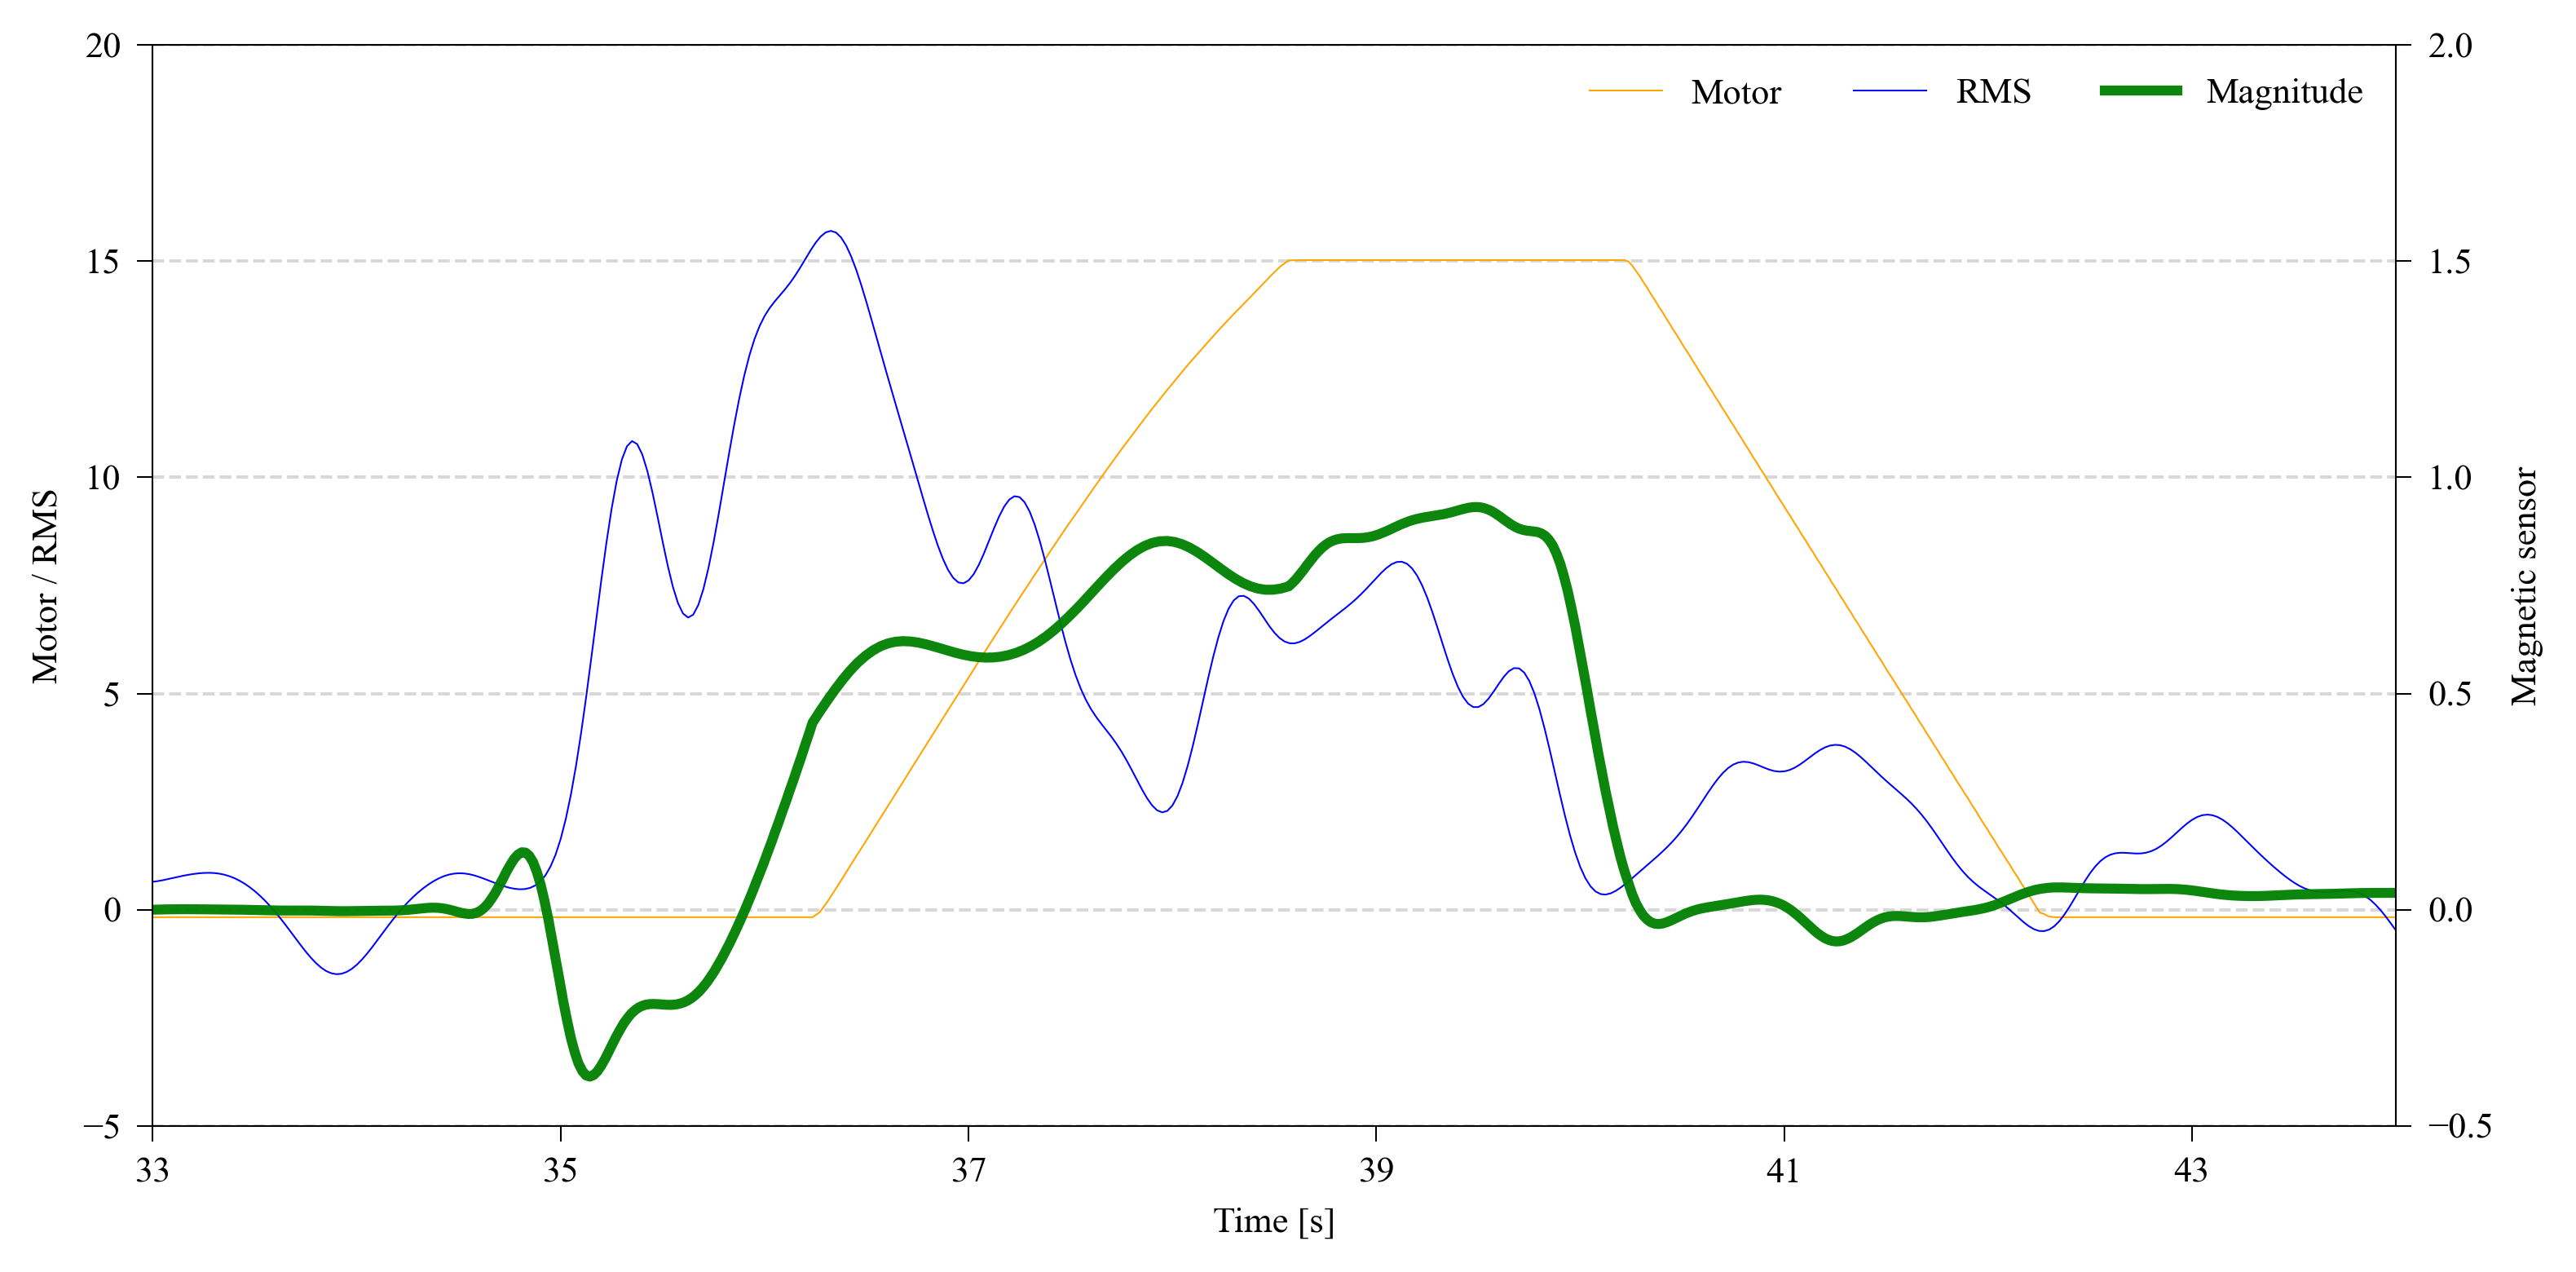

In [219]:
filt_ins = Filtering(fs = 40)

emg_data = RMS_dict['test']

emg_data = filt_ins.lowpass_filter(emg_data.reshape(-1, 3), cutoff = 2, order = 4)[0].reshape(emg_data.shape)
filtered_mag = filt_ins.lowpass_filter(mag_sen, cutoff = 2, order = 4)[0]

# ==========================================
# Time vectors
# ==========================================
RMS_time = np.arange(
    RMS_dict['test'].reshape(-1, 3).shape[0]
) / RMS_FREQ

# ==========================================
# Signals
# ==========================================
motor_signal = motor_rad
mag_signal = filtered_mag * -1
rms_signal = emg_data.reshape(-1, 3).mean(axis=1) * 100

# Baseline magnetometer
mag_signal = mag_signal - mag_signal[np.argmin(np.abs(esp_time - 33))]

# ==========================================
# Figure
# ==========================================
fig, ax1 = plt.subplots(figsize=(8, 4))

# ==========================================
# Left axis
# ==========================================
line1 = ax1.plot(
    esp_time,
    motor_signal,
    label='Motor',
    color='orange',
    zorder=3
)

line2 = ax1.plot(
    RMS_time,
    rms_signal,
    label='RMS',
    color='blue',
    zorder=4
)

ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Motor / RMS')

ax1.set_xlim(33, 44)
ax1.set_xticks(np.arange(33, 45, 2))

# Grid
ax1.grid(
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    axis = 'y'
)

# Cleaner appearance
ax1.spines['top'].set_visible(False)

# ==========================================
# Right axis (Magnetic sensor)
# ==========================================
ax2 = ax1.twinx()

line3 = ax2.plot(
    esp_time,
    mag_signal,
    label='Magnitude',
    color='green',
    linewidth=2.2,
    alpha=0.95,
    zorder=2
)

ax2.set_ylabel('Magnetic sensor')

ax1.set_ylim(-5, 20)
ax2.set_ylim(0, 2)

# ==========================================
# Align zero between y-axes
# ==========================================
y1_min, y1_max = ax1.get_ylim()

zero_pos = (0 - y1_min) / (y1_max - y1_min)

y2_min, y2_max = ax2.get_ylim()

range2 = max(
    abs(y2_max / (1 - zero_pos)),
    abs(y2_min / zero_pos)
)

new_y2_min = -zero_pos * range2
new_y2_max = (1 - zero_pos) * range2

ax2.set_ylim(new_y2_min, new_y2_max)

# ==========================================
# Combined legend
# ==========================================
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]

ax1.legend(
    lines,
    labels,
    loc='upper right',
    frameon=False,
    ncol=3
)

plt.savefig('exo_model_demonstration_signals.png', dpi=400)
plt.savefig('exo_model_demonstration_signals.pdf', dpi=400)
plt.tight_layout()
plt.show()

### Plot

indexNoExo
indexPassivExo
indexActiveExo


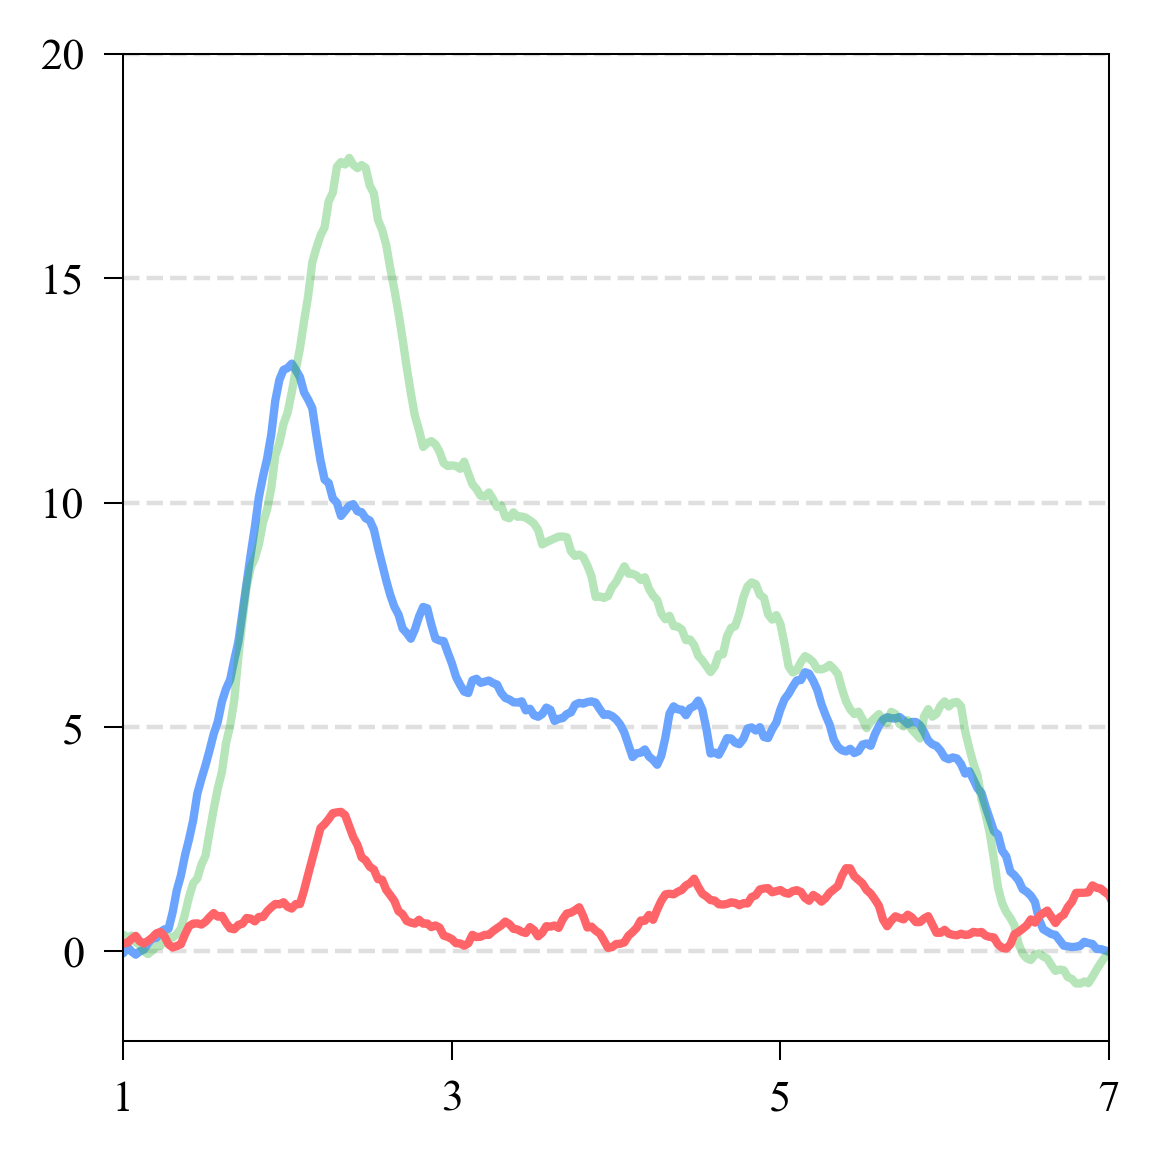

In [108]:
# =========================
# Motion groups
# =========================
motion_groups = {
    "no_exo": [
        'NoExo0kg',
        'NoExo0.25kg',
        'NoExo0.5kg',
        'NoExo0.75kg',
        'NoExo1kg'
    ],

    "active_exo": [
        'ActiveExo0kg',
        'ActiveExo0.25kg',
        'ActiveExo0.5kg',
        'ActiveExo0.75kg',
        'ActiveExo1kg'
    ],

    "index_isobend": [
        'indexNoExo',
        'indexPassivExo',
        'indexActiveExo'
    ],

    "thumb_isobend": [
        'thumbNoExo',
        'thumbPassivExo',
        'thumbActiveExo'
    ],

    "pinch_isobend": [
        'pinchNoExo',
        'pinchPassivExo',
        'pinchActiveExo'
    ]
}

# =========================
# Shared colors
# =========================
weight_colors = {
    "0kg": "#FF3DBE",
    "0.25kg": "#3DD8FF",
    "0.5kg": "#983DFF",
    "0.75kg": "#FF6469",
    "1kg": "#83FFA0",
}

condition_colors = {
    "NoExo": "#6ba4ffff",
    "PassivExo": "#2db63859",
    "ActiveExo": "#ff6469ff",
}

# =========================
# Colors
# =========================
motion_colors = {

    # No exo
    'NoExo0kg': weight_colors["0kg"],
    'NoExo0.25kg': weight_colors["0.25kg"],
    'NoExo0.5kg': weight_colors["0.5kg"],
    'NoExo0.75kg': weight_colors["0.75kg"],
    'NoExo1kg': weight_colors["1kg"],

    # Active exo
    'ActiveExo0kg': weight_colors["0kg"],
    'ActiveExo0.25kg': weight_colors["0.25kg"],
    'ActiveExo0.5kg': weight_colors["0.5kg"],
    'ActiveExo0.75kg': weight_colors["0.75kg"],
    'ActiveExo1kg': weight_colors["1kg"],

    # Index
    'indexNoExo': condition_colors["NoExo"],
    'indexPassivExo': condition_colors["PassivExo"],
    'indexActiveExo': condition_colors["ActiveExo"],

    # Thumb
    'thumbNoExo': condition_colors["NoExo"],
    'thumbPassivExo': condition_colors["PassivExo"],
    'thumbActiveExo': condition_colors["ActiveExo"],

    'pinchNoExo': condition_colors["NoExo"],
    'pinchPassivExo': condition_colors["PassivExo"],
    'pinchActiveExo': condition_colors["ActiveExo"],
}

# =========================
# Labels
# =========================
motion_labels = {

    # No exo
    'NoExo0kg': "No exoskeleton 0kg",
    'NoExo0.25kg': "No exoskeleton 0.25kg",
    'NoExo0.5kg': "No exoskeleton 0.5kg",
    'NoExo0.75kg': "No exoskeleton 0.75kg",
    'NoExo1kg': "No exoskeleton 1kg",

    # Active exo
    'ActiveExo0kg': "Active exoskeleton 0kg",
    'ActiveExo0.25kg': "Active exoskeleton 0.25kg",
    'ActiveExo0.5kg': "Active exoskeleton 0.5kg",
    'ActiveExo0.75kg': "Active exoskeleton 0.75kg",
    'ActiveExo1kg': "Active exoskeleton 1kg",

    # Index
    'indexNoExo': "Index no exoskeleton",
    'indexPassivExo': "Index passive exoskeleton",
    'indexActiveExo': "Index active exoskeleton",

    # Thumb
    'thumbNoExo': "Thumb no exoskeleton",
    'thumbPassivExo': "Thumb passive exoskeleton",
    'thumbActiveExo': "Thumb active exoskeleton",

    # Pinch
    'pinchNoExo': "Pinch no exoskeleton",
    'pinchPassivExo': "Pinch passive exoskeleton",
    'pinchActiveExo': "Pinch active exoskeleton",
}

# Plot sequence EMG activity
plot_EMG_activity(RMS_dict = selected_data, RMS_FREQ = RMS_FREQ, motion_colors = motion_colors, motion_labels = motion_labels, active_keys = motion_groups['index_isobend'])

# plot_metabolic_raincloud(effort_dict = effort_dict, motion_list = motion_groups['thumb_isobend'], modality_colors = motion_colors, savefig = False)


In [116]:
effort_dict['pinchActiveExo'].shape

(7,)

### Demonstration of Real-Time Hand Motion Classification

### Data

In [44]:
#=====================================#
# Arange true labels for demostration #
#=====================================#
label_order = ['thumb', 'index', 'middle', 'ring', 'pinky', 'pinch', 'cylinder']
trials = 10
true_labels = []
for label in label_order:
    for trial in range(trials):
        true_labels.append(label)

true_labels = np.array(true_labels)

#=====================================================#
# Observed results from the model during demostration #
#=====================================================#
observed_labels = np.array(['thumb', 'thumb', 'thumb', 'thumb', 'thumb', 'thumb', 'thumb', 'thumb', 'cylinder', 'thumb',                             # (1) semi correct
                            'index', 'index', 'index', 'index', 'index', 'index', 'index', 'index', 'index', 'index',
                            'thumb', 'middle', 'cylinder', 'cylinder', 'cylinder', 'cylinder', 'cylinder', 'cylinder', 'cylinder', 'cylinder',       # (8) semi correct - 11 motions was for some reason recorded int video
                            'cylinder', 'cylinder', 'cylinder', 'ring', 'cylinder', 'ring', 'ring', 'ring', 'ring', 'ring',                          # (3) semi correct - 11 motions was for some reason recorded int video  
                            'index', 'pinky', 'pinch', 'index', 'index', 'index', 'index', 'index', 'index', 'index',                                # (8) - semi correct
                            'index', 'index', 'index', 'pinky', 'index', 'index', 'index', 'index', 'index', 'pinch',                                # (3)
                            'cylinder', 'cylinder', 'cylinder', 'cylinder', 'cylinder', 'cylinder', 'cylinder', 'cylinder', 'middle', 'middle',  # (2) semi incorrect
                            ])

# Incorrect offsets
# Pinch had 1
# cylinder had 4

### Functions

In [53]:
def plot_semi_demonstration_results(results):
    # ======================
    # Plot settings
    # ======================
    motions = results["motion"]

    correct = results["correct"]
    semi = results["semi_correct"]
    incorrect = results["incorrect"]

    x = np.arange(len(motions))
    width = 0.7

    fig, ax = plt.subplots(figsize=(7.2, 4.2))

    # ======================
    # Stacked bars
    # ======================
    bars1 = ax.bar(
        x,
        correct,
        width,
        label='Correct',
        edgecolor='black',
        color = "#39F742",
        linewidth=0.6,
        alpha=0.9
    )

    bars2 = ax.bar(
        x,
        semi,
        width,
        bottom=correct,
        label='Semi-correct',
        edgecolor='black',
        color = "#F7E339",
        linewidth=0.6,
        alpha=0.9
    )

    bars3 = ax.bar(
        x,
        incorrect,
        width,
        bottom=correct + semi,
        label='Incorrect',
        edgecolor='black',
        color = "#F74242",
        linewidth=0.6,
        alpha=0.9
    )

    # ======================
    # Add values inside bars
    # ======================
    for bars in [bars1, bars2, bars3]:

        for bar in bars:

            height = bar.get_height()

            if height > 0:

                ax.text(
                    bar.get_x() + bar.get_width()/2,
                    bar.get_y() + height/2,
                    f"{int(height)}",
                    ha='center',
                    va='center',
                    fontsize=9,
                    fontweight='bold'
                )

    # ======================
    # Axes styling
    # ======================
    ax.set_xticks(x)
    ax.set_xticklabels(motions)

    ax.set_ylabel("Number of repetitions")
    ax.set_xlabel("Motion class")

    ax.set_ylim(0, 10.5)

    # Clean grid
    ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.5)

    # Remove top/right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Legend
    ax.legend(
        frameon=False,
        ncols=3,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.12)
    )

    plt.tight_layout()

    plt.savefig("demoModel_label_distribution.pdf", dpi = 400, bbox_inches='tight')
    plt.savefig("demoModel_label_distribution.png", dpi = 400, bbox_inches='tight')

    plt.show()
    
def plot_confusion_matrix(all_labels, all_predictions, label_order):
    import seaborn as sns

    cm = confusion_matrix(
        all_labels,
        all_predictions,
        labels=label_order
    )
    print(cm)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    cm_norm = cm_norm * 100

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm_norm,
        annot=True,
        fmt='.0f',
        cmap='Blues',
        xticklabels=label_order,
        yticklabels=label_order
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    # plt.title("Confusion Matrix")

    plt.tight_layout()
    plt.savefig('confusion_matrix_demonstration.png', dpi=400)
    plt.savefig('confusion_matrix_demonstration.pdf', dpi=400)
    plt.show()

    total = len(all_labels)
    correct = np.sum(all_labels == all_predictions)

    acc = correct / total * 100 if total > 0 else 0

    print(f"\nFinal Accuracy: {acc:.2f}%")
    print(f"Correct: {correct}/{total}")

def plot_confusion_matrix_updated(all_labels, all_predictions, label_order):
    
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import confusion_matrix

    # =========================
    # Compute confusion matrix
    # =========================
    cm = confusion_matrix(
        all_labels,
        all_predictions,
        labels=label_order
    )

    # Row-normalized confusion matrix
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    # Avoid NaN if a row is empty
    cm_norm = np.nan_to_num(cm_norm)

    # Convert to percentage
    cm_percent = cm_norm * 100

    # =========================
    # Custom annotation strings
    # =========================
    annot = np.empty_like(cm_percent, dtype=object)

    for i in range(cm_percent.shape[0]):
        for j in range(cm_percent.shape[1]):

            value = cm_percent[i, j]

            # No decimals for exact zeros
            if np.isclose(value, 0):
                annot[i, j] = "0"

            # Integer if very close to whole number
            elif np.isclose(value, round(value)):
                annot[i, j] = f"{int(round(value))}"

            # Otherwise one decimal
            else:
                annot[i, j] = f"{value:.1f}"

    # =========================
    # Plot
    # =========================
    plt.figure(figsize=(7, 5.5))

    ax = sns.heatmap(
        cm_percent,
        annot=annot,
        fmt="",
        cmap="Blues",
        vmin=0,
        vmax=100,
        linewidths=0.5,          # Small borders
        linecolor='white',
        square=True,
        cbar_kws={"label": "Accuracy (%)"},
        xticklabels=label_order,
        yticklabels=label_order
    )

    # Labels
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    # Better tick appearance
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)

    # Tight layout
    plt.tight_layout()

    # Optional saves

    plt.show()

    # =========================
    # Accuracy
    # =========================
    total = len(all_labels)
    correct = np.sum(np.array(all_labels) == np.array(all_predictions))

    acc = correct / total * 100 if total > 0 else 0

    print(f"\nFinal Accuracy: {acc:.2f}%")
    print(f"Correct: {correct}/{total}")

### Results

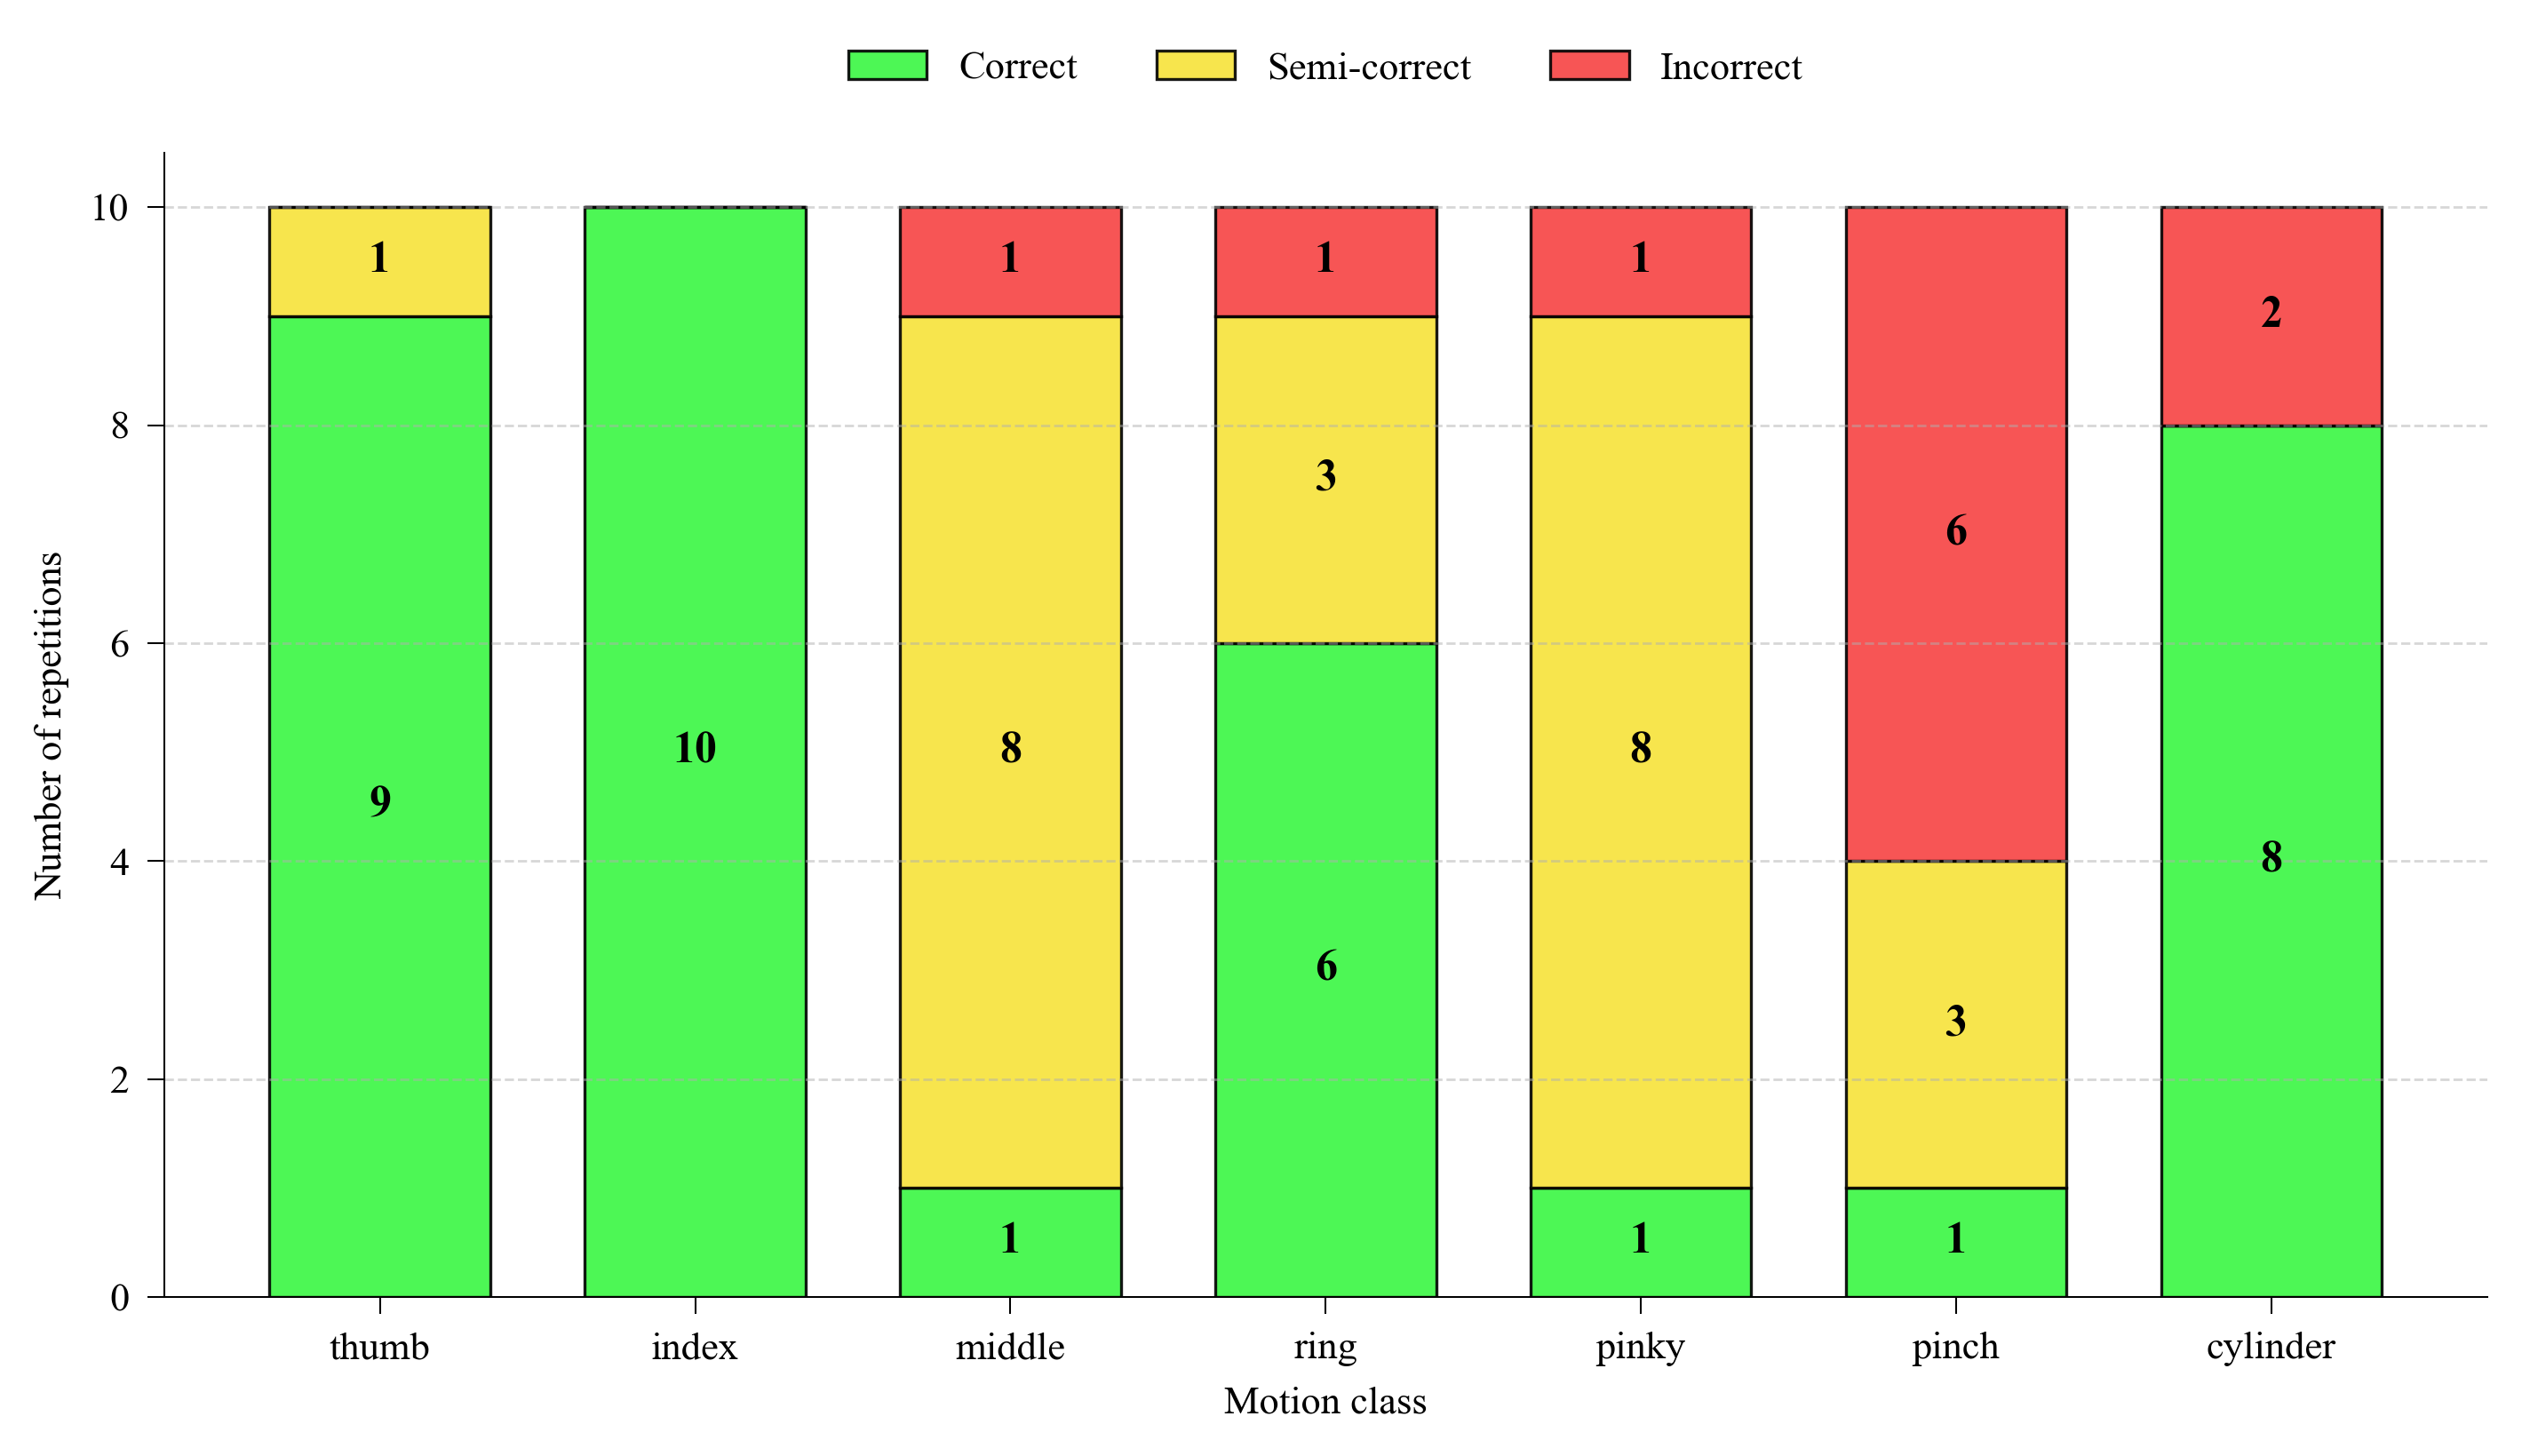

In [54]:
# plot_confusion_matrix(all_labels = true_labels, all_predictions = observed_labels, label_order = label_order)
# plot_confusion_matrix_updated(all_labels = true_labels, all_predictions = observed_labels, label_order = label_order)


# ======================
# Data
# ======================
results = pd.DataFrame({
    "motion": ["thumb", "index", "middle", "ring", "pinky", "pinch", "cylinder"],
    "correct":      [9, 10, 1, 6, 1, 1, 8],
    "semi_correct": [1, 0, 8, 3, 8, 3, 0],
    "incorrect":    [0, 0, 1, 1, 1, 6, 2],
})


plot_semi_demonstration_results(results)

## Hyperparameters

### Load 

In [13]:
base_dir = Path().resolve() / 'loggings'
model_path_folder = 'real_time/fine_tune/SingleNet_CNN+LSTM_EMG_newCrop_3motions/SingleNet_CNN+LSTM_EMG/subject_0'

model_path = base_dir / model_path_folder / 'model.pth'
checkpoint = torch.load(f = model_path, map_location = 'cpu')

print(checkpoint["model_args"])
model_args = checkpoint["model_args"]

{'input_dim': 3, 'output_dim': 7, 'hidden_dim': 128, 'lstm_layers': 2, 'bidirectional': False, 'dropout': 0.14853567226828412, 'activation': 'elu', 'dense_ratio': 0.25, 'cnn_filters': 64, 'kernel_size': 9}


## Latency analysis

In [30]:
# "middle" : {
#     "onset" : [0, 1.259999, 1.6, 1.8, 1.8, 1.7, 1.6, 1.7, 1.7, 1.8],
#     "onset_cor" : [0, 0.0, 0.0999, 0.030378056, 0.05000, 0.05, 0.08, 0.05, 0.0999999999999972, 0.10062075],
#     "offset" : [0, 0.3,  0.359,  0.23, 0.42, 0.18, 0.32, 0.17, 0.39, 0.42],
#     "offset_cor" : np.zeros(10),
# }

#     "middle" : {
#         "onset" : [0, 0.59934711, 0.505265710, 0.20261931, 0.20536995, 0.19712543, 0.50358772, 0.30555129, 0.50475931,  0.2022593],
#         "onset_cor" : [0, 0.0, 0.10155058, 0.30378056, 0.39675045, 0.50302792, 0.1119349,  0.09856081, 0.10062075, 0.40358424],
#         "offset" : [0, 0.4013207,  0.5019362,  0.20014763, 0.20327687, 0.40250969, 0.41179085, 0.19878936, 0.70299792, 0.30787873],
#         "offset_cor" : np.zeros(10),
#     },

42

In [8]:
import pickle

# with open("cylinder_latency_loggers.pkl", "rb") as f:
#     loaded_loggers = pickle.load(f)

latency_results = {
    "thumb" : {
        "onset" : [0.25690618, 0.20071745, 0.2075119,  0.20361423, 0.61787081, 0.20219231, 0.30937862, 0.20569921, 0.1991508, 0.23688078],
        "onset_cor" : [0, 0, 0, 0, 0, 0, 0, 0, 0.1991508 , 0],
        "offset" : [0.20495629, 0.20343351, 0.19846463, 0.20352745, 0.20706868, 0.60139823, 0.20072174, 0.20114589, 0.19506431, 0.21522784],
        "offset_cor" : np.zeros(10),
    },
    "index" : {
        "onset" : [0.40298963, 0.19327474, 0.29456282, 0.2036705 , 0.20332575, 0.20030379, 0.30169845, 0.20441508, 0.39857149, 0.20257854],
        "onset_cor" : np.zeros(10),
        "offset" : [0.2067945 , 0.20345521, 0.40591764, 0.30066466, 0.20035815, 0.20186663, 0.21190977, 0.40228558, 0.2003777 , 0.20065212],
        "offset_cor" : np.zeros(10),
    },
    "middle" : {
        "onset" : [0, 0.59934711, 0.505265710, 0.20261931, 0.20536995, 0.19712543, 0.50358772, 0.30555129, 0.50475931,  0.2022593],
        "onset_cor" : [0, 0.0, 0.10155058, 0.30378056, 0.39675045, 0.50302792, 0.1119349,  0.09856081, 0.10062075, 0.40358424],
        "offset" : [0, 0.4013207,  0.5019362,  0.20014763, 0.20327687, 0.40250969, 0.41179085, 0.19878936, 0.70299792, 0.30787873],
        "offset_cor" : np.zeros(10),
    },
    "ring" : {
        "onset" : [0.79605603, 0.31699204 , 0.61623955, 6.33068347, 0.40178943, 0.40377331, 0.40753698, 0.40245533, 0.60253644, 0.90559578],
        "onset_cor" : [0.10499883, 0.10053706, 0.10140514, 0, 0.10079885, 0, 0, 0, 0, 0],
        "offset" : [0.20719266, 0.20347309, 0.19992137, 0.39513493, 0.20457387, 0.30572867, 0.50240493, 0.20461535, 0.50413442, 0.20247197],
        "offset_cor" : np.zeros(10),
    },
    "pinky" : {
        "onset" : [0.20520854, 1.00189114, 0.3019352, 0.19911075, 0.20180845, 0.20556664, 0.20252681, 0.19795895, 0.0, 0.20381784],
        "onset_cor" : [0.40009308, 0.0, 0.10018325, 1.91819119, 0.60200834, 2.00969505, 1.50544667, 1.11276746, 0, 0.90261626],
        "offset" : [0.20331645, 0.20146704, 0.19494796, 0.20042229, 0.19802213, 0.20133901, 0.19949389, 0.20018768, 0, 0.2990284],
        "offset_cor" : np.zeros(10),
    },
    "pinch" : {
        "onset" : [0, 0, 0.39788127, 0.19946671, 0, 0.20145059, 0, 0, 0, 0.19832754],
        "onset_cor" : [0, 0, 0.50496507, 2.62580538, 0, 1.01797795, 0, 0, 0, 0],
        "offset" : [0, 0, 0.234391, 0.2490396, 0, 6.19464111, 0, 0, 0, 0.28961468],
        "offset_cor" : np.zeros(10),
    },
    "cylinder" : {
        "onset" : [0.20117235, 0.50574732, 0.211375, 0.50165629, 0.50264144, 0, 0.50335026, 0.40363717, 0, 0.50457978],
        "onset_cor" : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        "offset" : [0.198879, 0.2068038, 11.2749461, 7.2068038, 0.2068038, 0.80421305, 6.18625951, 0.39599895, 0, 0.20175028],
        "offset_cor" : np.zeros(10),
    },
}
# 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

# finger = 'middle'
# print('onset')
# print(loaded_loggers['on_latency_logger'][finger])
# print('\nOnset self-correction')
# print(loaded_loggers['on_correction_logger'][finger])
# print('\noffset')
# print(loaded_loggers['off_latency_logger'][finger])
# print('\noffset self-correction')
# print(loaded_loggers['off_latency_logger'][finger])

latency_results["index"]

{'onset': [0.40298963,
  0.19327474,
  0.29456282,
  0.2036705,
  0.20332575,
  0.20030379,
  0.30169845,
  0.20441508,
  0.39857149,
  0.20257854],
 'onset_cor': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'offset': [0.2067945,
  0.20345521,
  0.40591764,
  0.30066466,
  0.20035815,
  0.20186663,
  0.21190977,
  0.40228558,
  0.2003777,
  0.20065212],
 'offset_cor': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])}

In [20]:
corr_collection = []
self_corr = []
offset = []
for ml in latency_results.keys():
    latency = latency_results[ml]['onset']

    for lat in latency:
        if lat != 0:
            corr_collection.append(lat)
    
    latency = latency_results[ml]['onset_cor']
    for lat in latency:
        if lat != 0:
            self_corr.append(lat)

    latency = latency_results[ml]['offset']
    for lat in latency:
        if lat != 0:
            offset.append(lat)

np.mean(corr_collection), np.std(corr_collection), np.mean(self_corr), np.std(self_corr), np.mean(offset), np.std(offset), 

(0.4450994435,
 0.7882957797404533,
 0.6386021079166667,
 0.6999506412119072,
 0.7667862175409836,
 1.9219203141449697)

### Functions

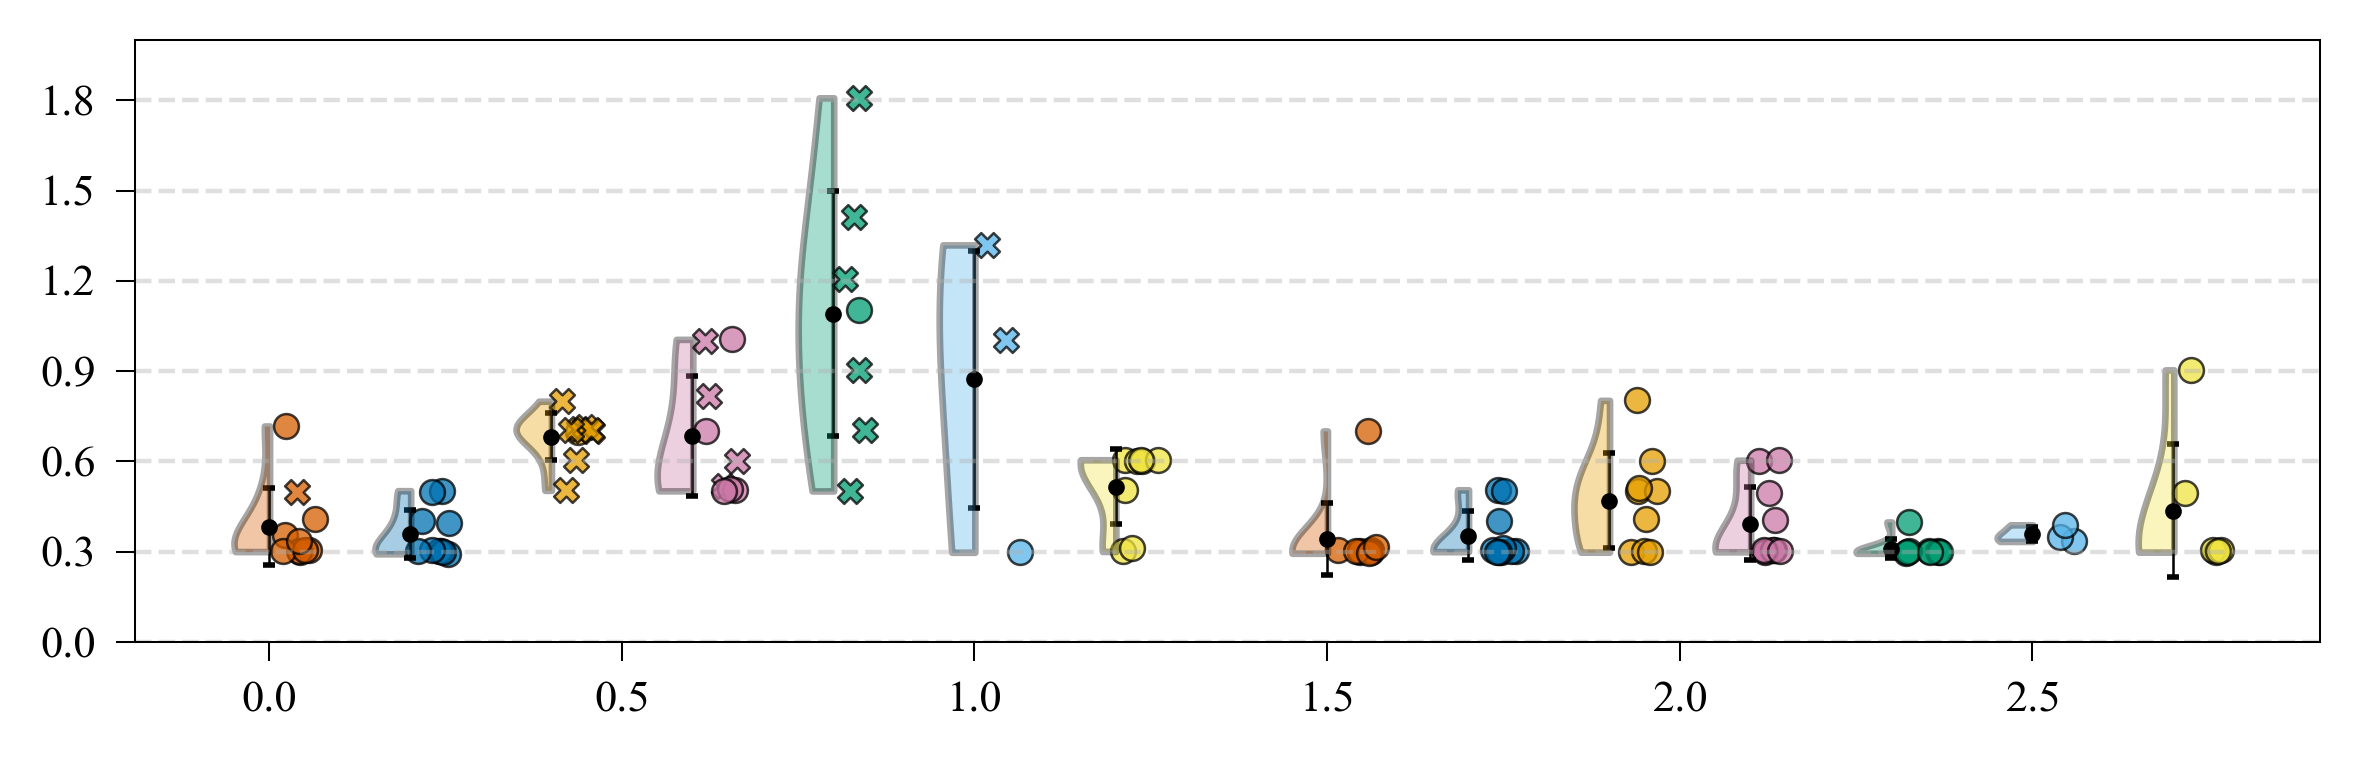

In [196]:
def plot_latency_raincloud(latency_results, motion_list, modality_colors, savefig=False):

    import numpy as np
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(6, 2))

    # =====================================
    # Layout
    # =====================================
    n_motions = len(motion_list)

    group_spacing = 0.2
    gap = 0.1

    onset_positions = np.arange(n_motions) * group_spacing

    offset_positions = (
        np.arange(n_motions) * group_spacing
        + onset_positions[-1]
        + group_spacing
        + gap
    )

    # =====================================
    # Loop motions
    # =====================================
    for i, motion in enumerate(motion_list):

        conditions = [
            ("onset", "onset_cor", onset_positions[i]),
            ("offset", "offset_cor", offset_positions[i]),
        ]

        # =====================================
        # Plot onset/offset
        # =====================================
        for base_key, cor_key, pos in conditions:

            base_data = np.asarray(latency_results[motion][base_key])
            cor_data = np.asarray(latency_results[motion][cor_key])

            # =====================================
            # Remove invalid samples
            # =====================================
            valid_mask = (base_data > 0) #& (base_data < 1)

            base_data = base_data[valid_mask]
            cor_data = cor_data[valid_mask]

            color = modality_colors[motion]

            # =====================================
            # Build total data
            # =====================================
            total_data = base_data + cor_data + 0.1

            # =====================================
            # SCATTER POINTS
            # =====================================
            for sample_idx in range(len(total_data)):        # base_data

                y = total_data[sample_idx]

                if y == 0:
                    continue

                jitter = np.random.uniform(0.01, 0.07)
                x = pos + jitter

                if cor_data[sample_idx] > 0:

                    ax.scatter(
                        x,
                        y,
                        marker='X',
                        s=20,
                        alpha=0.75,
                        color=color,
                        edgecolors='black',
                        linewidths=0.454,
                        zorder=1
                    )

                else:

                    ax.scatter(
                        x,
                        y,
                        marker='o',
                        s=20,
                        alpha=0.75,
                        color=color,
                        edgecolors='black',
                        linewidths=0.454,
                        zorder=1
                    )

            valid_mask = (total_data < 2)     # 2

            total_data = total_data[valid_mask]
            # =====================================
            # Mean ± std
            # =====================================
            if len(total_data) > 0:

                mean = np.mean(total_data)
                std = np.std(total_data)

                ax.errorbar(
                    pos,
                    mean,
                    yerr=std,
                    fmt='o',
                    color='black',
                    markersize=2,
                    capsize=1,
                    linewidth=0.454,
                    zorder=1
                )

            # =====================================
            # HALF VIOLIN
            # =====================================
            violin = ax.violinplot(
                dataset=total_data,
                positions=[pos],
                widths=0.1,
                showmeans=False,
                showmedians=False,
                showextrema=False
            )

            for body in violin['bodies']:

                verts = body.get_paths()[0].vertices
                center = np.mean(verts[:, 0])

                # LEFT HALF
                verts[:, 0] = np.minimum(verts[:, 0], center)

                body.set_facecolor(color)
                body.set_edgecolor('black')
                body.set_alpha(0.35)
                body.set_linewidth(1.2)

    # =====================================
    # Formatting
    # =====================================
    all_positions = np.concatenate(
        [onset_positions, offset_positions]
    )

    all_labels = motion_list + motion_list

    # ax.set_xticks(all_positions)
    # ax.set_xticklabels(
    #     all_labels,
    #     rotation=45,
    #     ha='right'
    # )

    # ax.set_ylabel("Latency (s)")

    ax.grid(axis='y', linestyle='--', alpha=0.4)

    # For outliers
    step = (12 - 2) / 5  # 2.1
    # print(f'step {step}')

    # ax.set_ylim(0, 12.01)
    # ax.set_yticks(np.arange(2, 12.01, step))

    # Data of interest
    # ax.set_ylim(0, 2)
    # ax.set_yticks(np.arange(0, 2, 0.3))
    ax.set_ylim(0, 2)
    ax.set_yticks(np.arange(0, 2, 0.3))

    # =====================================
    # Group labels
    # =====================================
    # ax.text(
    #     np.mean(onset_positions),
    #     3.05,
    #     "Onset",
    #     ha='center',
    #     va='bottom',
    #     fontsize=10,
    #     fontweight='bold'
    # )

    # ax.text(
    #     np.mean(offset_positions),
    #     3.05,
    #     "Offset",
    #     ha='center',
    #     va='bottom',
    #     fontsize=10,
    #     fontweight='bold'
    # )

    plt.tight_layout()

    if savefig:
        plt.savefig("latency_raincloud.png", dpi=400)
        plt.savefig("latency_raincloud.pdf")

    plt.show()

plot_latency_raincloud(
    latency_results=latency_results,
    motion_list=["thumb", "index", "middle", "ring", "pinky", "pinch", "cylinder"],
    modality_colors = {
        "thumb":    "#D55E00",  # vermillion
        "index":    "#0072B2",  # blue
        "middle":   "#E69F00",  # orange
        "ring":     "#CC79A7",  # purple/pink
        "pinky":    "#009E73",  # green
        "pinch":    "#56B4E9",  # sky blue
        "cylinder": "#F0E442",  # yellow
    },
    savefig=True
)